In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

In [2]:

# Import each CSV as a separate variable
dual_mixed_mean = pd.read_csv('results/dual_mixed_linear_query_mean.csv', index_col=0)
dual_mixed_sem = pd.read_csv('results/dual_mixed_linear_query_sem.csv', index_col=0)
dual_random_mean = pd.read_csv('results/dual_random_linear_query_mean.csv', index_col=0)
dual_random_sem = pd.read_csv('results/dual_random_linear_query_sem.csv', index_col=0)
dual_sequential_mean = pd.read_csv('results/dual_sequential_linear_query_mean.csv', index_col=0)
dual_sequential_sem = pd.read_csv('results/dual_sequential_linear_query_sem.csv', index_col=0)

In [30]:
# Load all datasets for comparison (Mixed, Sequential, Random)
# Linear → Quadratic: first context is LINEAR, second context is QUADRATIC, query is QUADRATIC
linear_to_quad_mixed_mean = pd.read_csv('results/dual_mixed_quadratic_query_mean.csv', index_col=0)
linear_to_quad_mixed_sem = pd.read_csv('results/dual_mixed_quadratic_query_sem.csv', index_col=0)
linear_to_quad_sequential_mean = pd.read_csv('results/dual_sequential_quadratic_query_mean.csv', index_col=0)
linear_to_quad_sequential_sem = pd.read_csv('results/dual_sequential_quadratic_query_sem.csv', index_col=0)
linear_to_quad_random_mean = pd.read_csv('results/dual_random_quadratic_query_mean.csv', index_col=0)
linear_to_quad_random_sem = pd.read_csv('results/dual_random_quadratic_query_sem.csv', index_col=0)

# Quadratic → Linear: first context is QUADRATIC, second context is LINEAR, query is LINEAR  
quad_to_linear_mixed_mean = pd.read_csv('results/dual_mixed_linear_query_mean.csv', index_col=0)
quad_to_linear_mixed_sem = pd.read_csv('results/dual_mixed_linear_query_sem.csv', index_col=0)
quad_to_linear_sequential_mean = pd.read_csv('results/dual_sequential_linear_query_mean.csv', index_col=0)
quad_to_linear_sequential_sem = pd.read_csv('results/dual_sequential_linear_query_sem.csv', index_col=0)
quad_to_linear_random_mean = pd.read_csv('results/dual_random_linear_query_mean.csv', index_col=0)
quad_to_linear_random_sem = pd.read_csv('results/dual_random_linear_query_sem.csv', index_col=0)

# Rename columns to integers for all
all_dfs = [
    linear_to_quad_mixed_mean, linear_to_quad_mixed_sem,
    linear_to_quad_sequential_mean, linear_to_quad_sequential_sem,
    linear_to_quad_random_mean, linear_to_quad_random_sem,
    quad_to_linear_mixed_mean, quad_to_linear_mixed_sem,
    quad_to_linear_sequential_mean, quad_to_linear_sequential_sem,
    quad_to_linear_random_mean, quad_to_linear_random_sem
]

for df in all_dfs:
    rename_dict = {}
    for col in df.columns:
        if col.startswith('quadratic_'):
            rename_dict[col] = int(col.split('_')[1])
        elif col.startswith('linear_'):
            rename_dict[col] = int(col.split('_')[1])
    df.rename(columns=rename_dict, inplace=True)

print("Loaded all datasets (Mixed, Sequential, Random)")
print("Linear → Quadratic shape:", linear_to_quad_mixed_mean.shape)
print("Quadratic → Linear shape:", quad_to_linear_mixed_mean.shape)


Loaded all datasets (Mixed, Sequential, Random)
Linear → Quadratic shape: (13, 13)
Quadratic → Linear shape: (13, 13)


## Mixed

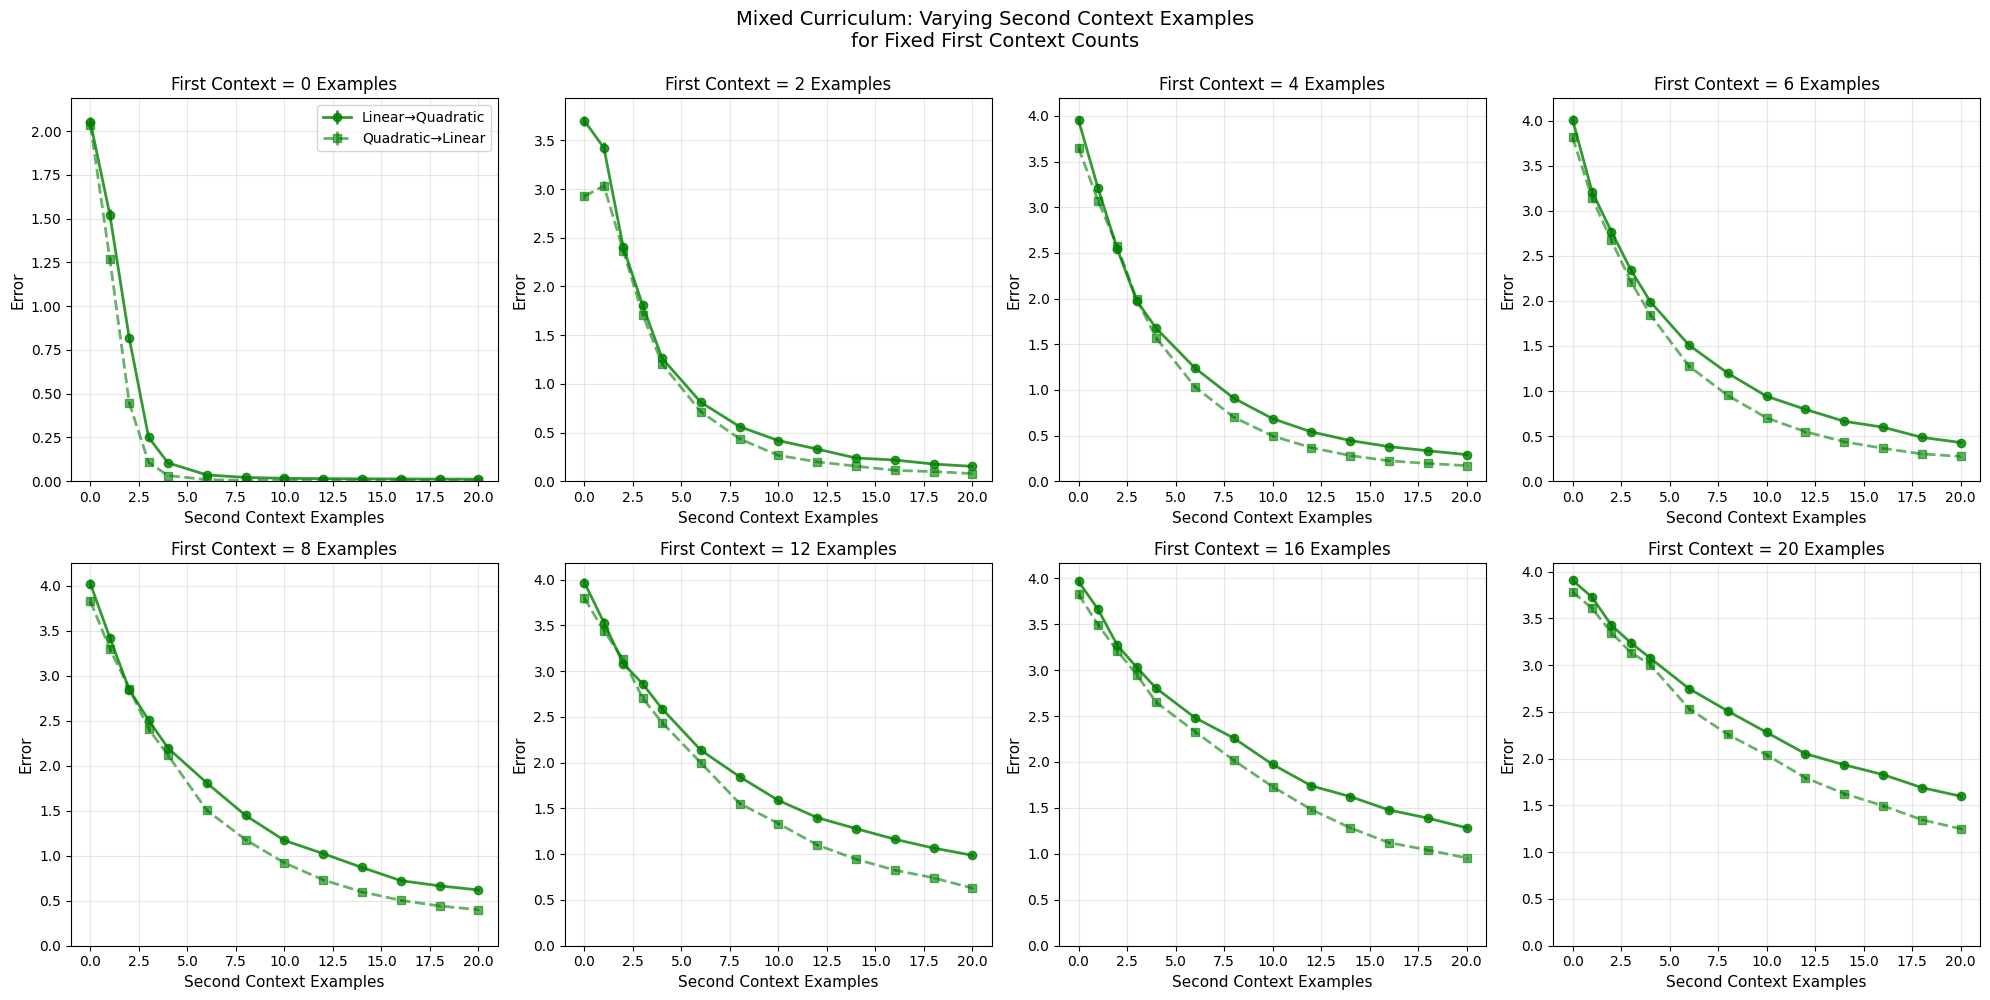

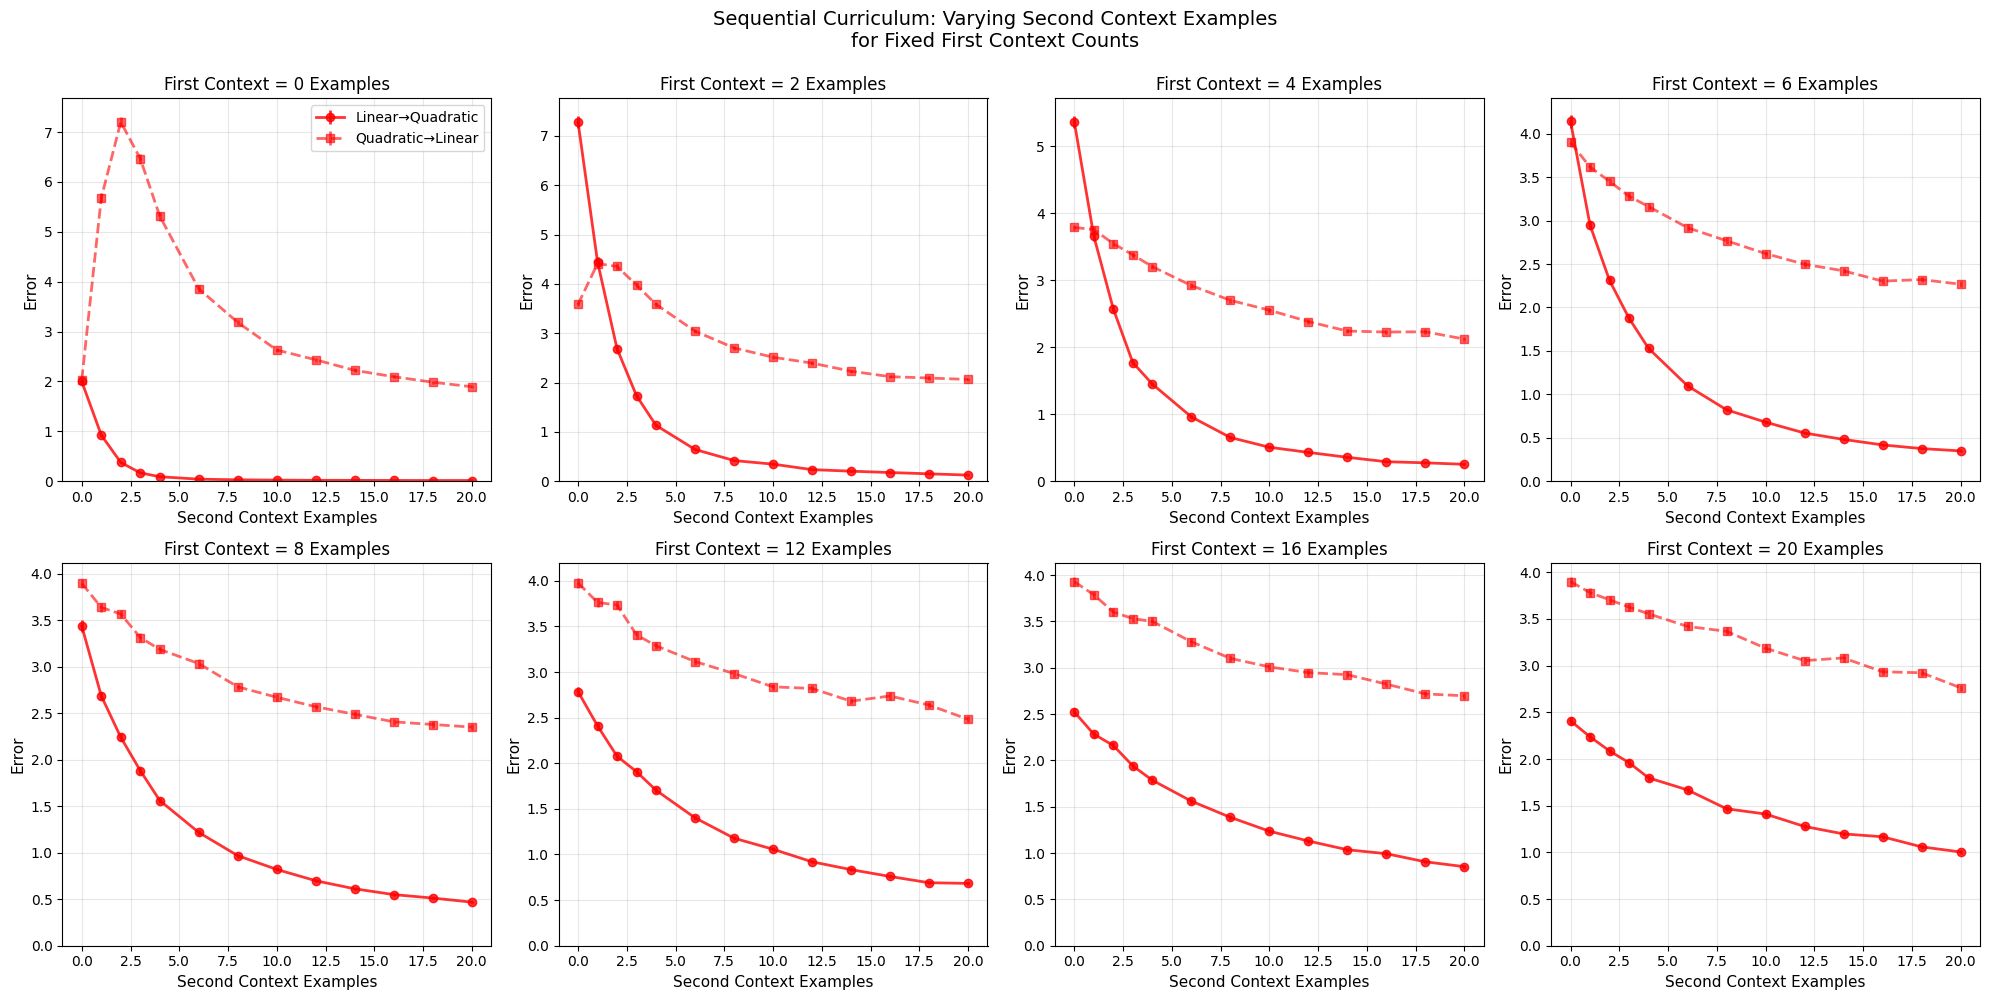

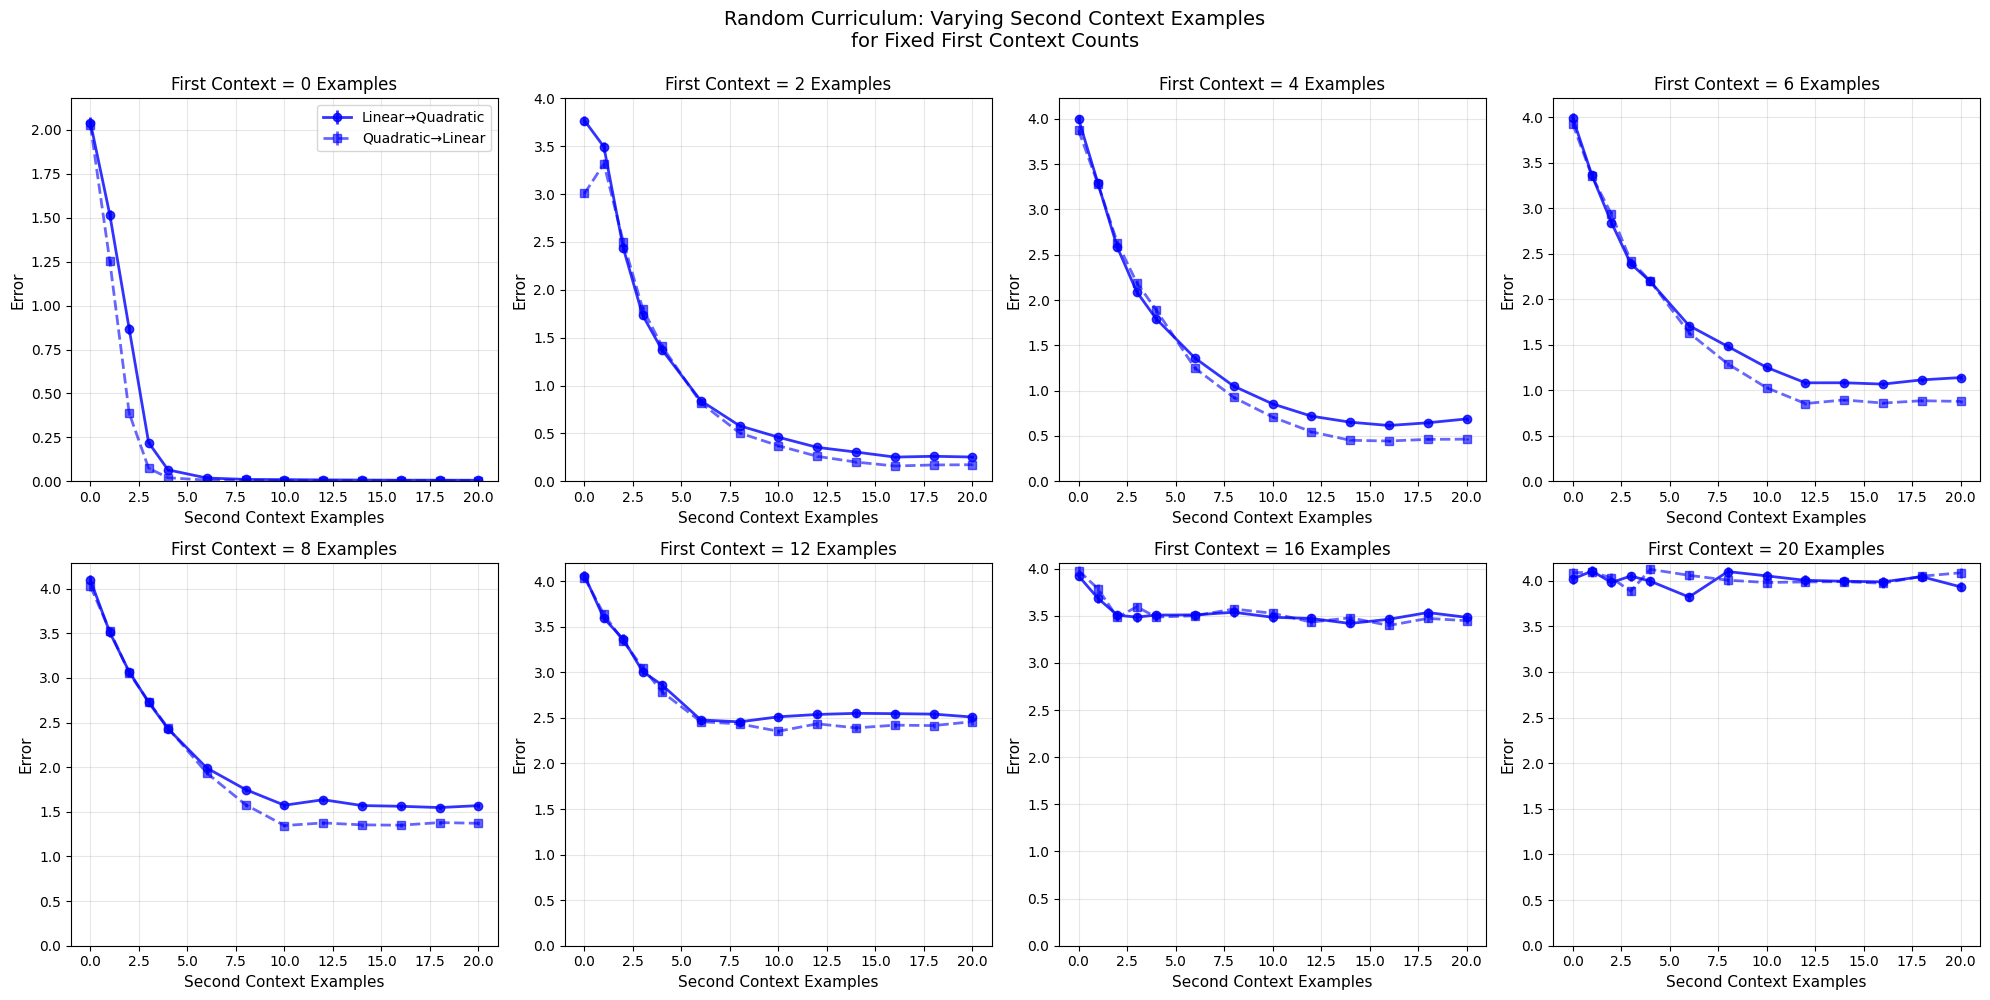

In [ ]:
# Figure 3: Line plots comparing specific scenarios - 2x3 format
# Show how error changes as we vary second context examples, for fixed first context counts

# Get the index/column values from mixed (they should be the same across curricula)
linear_first = linear_to_quad_mixed_mean.index.values
quadratic_second_ltq = linear_to_quad_mixed_mean.columns.values
quadratic_first = quad_to_linear_mixed_mean.index.values
linear_second_qtl = quad_to_linear_mixed_mean.columns.values

# Fixed first context counts - 6 values for 2x3 layout
first_context_counts = [0, 2, 4, 8, 12, 16]

# Graph 1: Sequential curriculum only
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, n_first in enumerate(first_context_counts):
    ax = axes[idx]
    
    # Linear → Quadratic: first context is LINEAR
    if n_first in linear_first:
        ltq_errors = linear_to_quad_sequential_mean.loc[n_first].values
        ltq_sem_vals = linear_to_quad_sequential_sem.loc[n_first].values
        ax.errorbar(quadratic_second_ltq, ltq_errors, yerr=ltq_sem_vals, 
                   marker='o', label='Linear→Quadratic', linewidth=2, 
                   markersize=6, color='red', alpha=0.8, capsize=4, capthick=1.5)
    
    # Quadratic → Linear: first context is QUADRATIC
    if n_first in quadratic_first:
        qtl_errors = quad_to_linear_sequential_mean.loc[n_first].values
        qtl_sem_vals = quad_to_linear_sequential_sem.loc[n_first].values
        ax.errorbar(linear_second_qtl, qtl_errors, yerr=qtl_sem_vals, 
                   marker='s', label='Quadratic→Linear', linewidth=2, 
                   markersize=6, color='red', alpha=0.6, linestyle='--', capsize=4, capthick=1.5)
    
    ax.set_xlabel('Second Context Examples', fontsize=22)
    ax.set_ylabel('Error', fontsize=22)
    ax.set_title(f'First Context = {n_first} Examples', fontsize=24)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)
    ax.tick_params(labelsize=22)

# Create a single shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, fontsize=24, 
           bbox_to_anchor=(0.5, 0.95), frameon=True)

plt.suptitle('Sequential Curriculum: Varying Second Context Examples\n' +
             'for Fixed First Context Counts', fontsize=28, y=1.0)
plt.tight_layout(rect=[0, 0, 1, 0.90])  # Leave space at top for legend and title
plt.show()

# Graph 2: Mixed and Random curricula together
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, n_first in enumerate(first_context_counts):
    ax = axes[idx]
    
    # Linear → Quadratic: first context is LINEAR
    if n_first in linear_first:
        # Mixed
        ltq_mixed_errors = linear_to_quad_mixed_mean.loc[n_first].values
        ltq_mixed_sem = linear_to_quad_mixed_sem.loc[n_first].values
        ax.errorbar(quadratic_second_ltq, ltq_mixed_errors, yerr=ltq_mixed_sem, 
                   marker='o', label='Mixed: L→Q', linewidth=2, 
                   markersize=6, color='green', alpha=0.8, capsize=4, capthick=1.5)
        
        # Random
        ltq_random_errors = linear_to_quad_random_mean.loc[n_first].values
        ltq_random_sem = linear_to_quad_random_sem.loc[n_first].values
        ax.errorbar(quadratic_second_ltq, ltq_random_errors, yerr=ltq_random_sem, 
                   marker='o', label='Random: L→Q', linewidth=2, 
                   markersize=6, color='blue', alpha=0.8, capsize=4, capthick=1.5)
    
    # Quadratic → Linear: first context is QUADRATIC
    if n_first in quadratic_first:
        # Mixed
        qtl_mixed_errors = quad_to_linear_mixed_mean.loc[n_first].values
        qtl_mixed_sem = quad_to_linear_mixed_sem.loc[n_first].values
        ax.errorbar(linear_second_qtl, qtl_mixed_errors, yerr=qtl_mixed_sem, 
                   marker='s', label='Mixed: Q→L', linewidth=2, 
                   markersize=6, color='green', alpha=0.6, linestyle='--', capsize=4, capthick=1.5)
        
        # Random
        qtl_random_errors = quad_to_linear_random_mean.loc[n_first].values
        qtl_random_sem = quad_to_linear_random_sem.loc[n_first].values
        ax.errorbar(linear_second_qtl, qtl_random_errors, yerr=qtl_random_sem, 
                   marker='s', label='Random: Q→L', linewidth=2, 
                   markersize=6, color='blue', alpha=0.6, linestyle='--', capsize=4, capthick=1.5)
    
    ax.set_xlabel('Second Context Examples', fontsize=22)
    ax.set_ylabel('Error', fontsize=22)
    ax.set_title(f'First Context = {n_first} Examples', fontsize=24)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)
    ax.tick_params(labelsize=22)

# Create a single shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, fontsize=24, 
           bbox_to_anchor=(0.5, 0.95), frameon=True)

plt.suptitle('Mixed & Random Curricula: Varying Second Context Examples\n' +
             'for Fixed First Context Counts', fontsize=28, y=1.0)
plt.tight_layout(rect=[0, 0, 1, 0.90])  # Leave space at top for legend and title
plt.show()


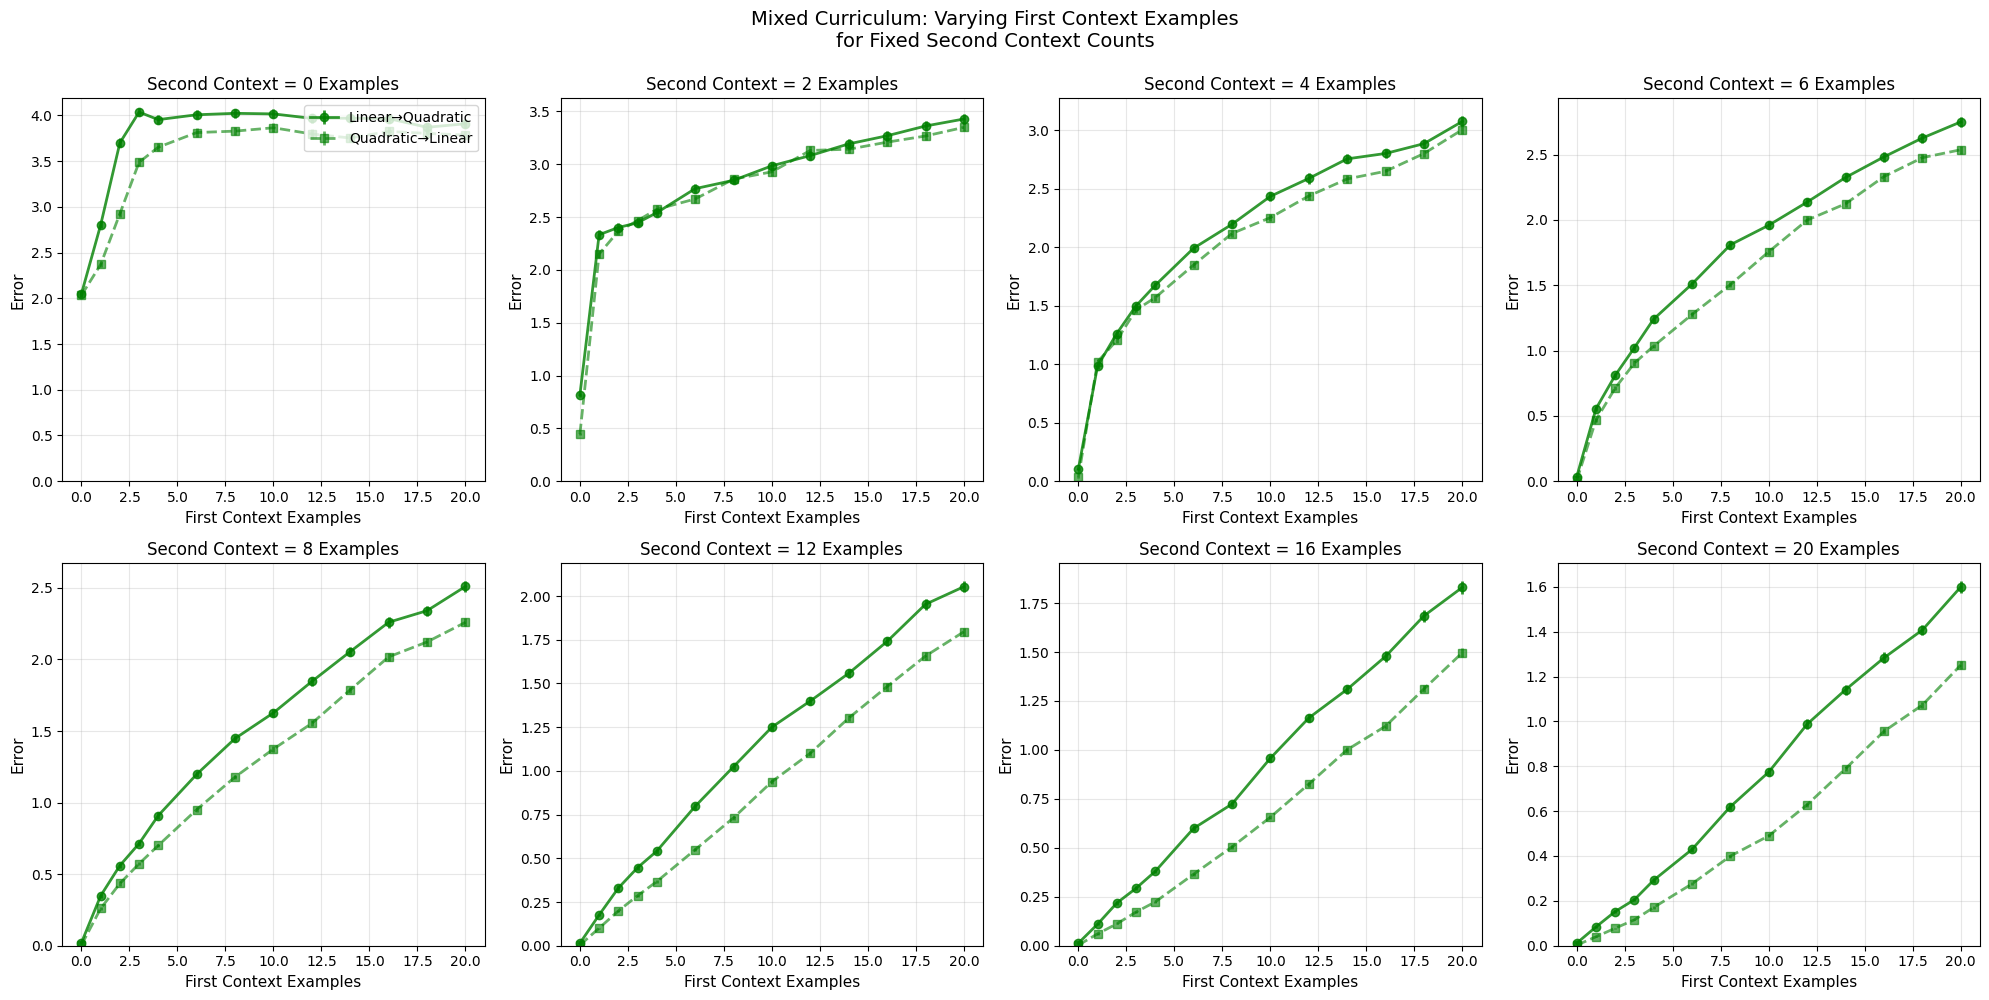

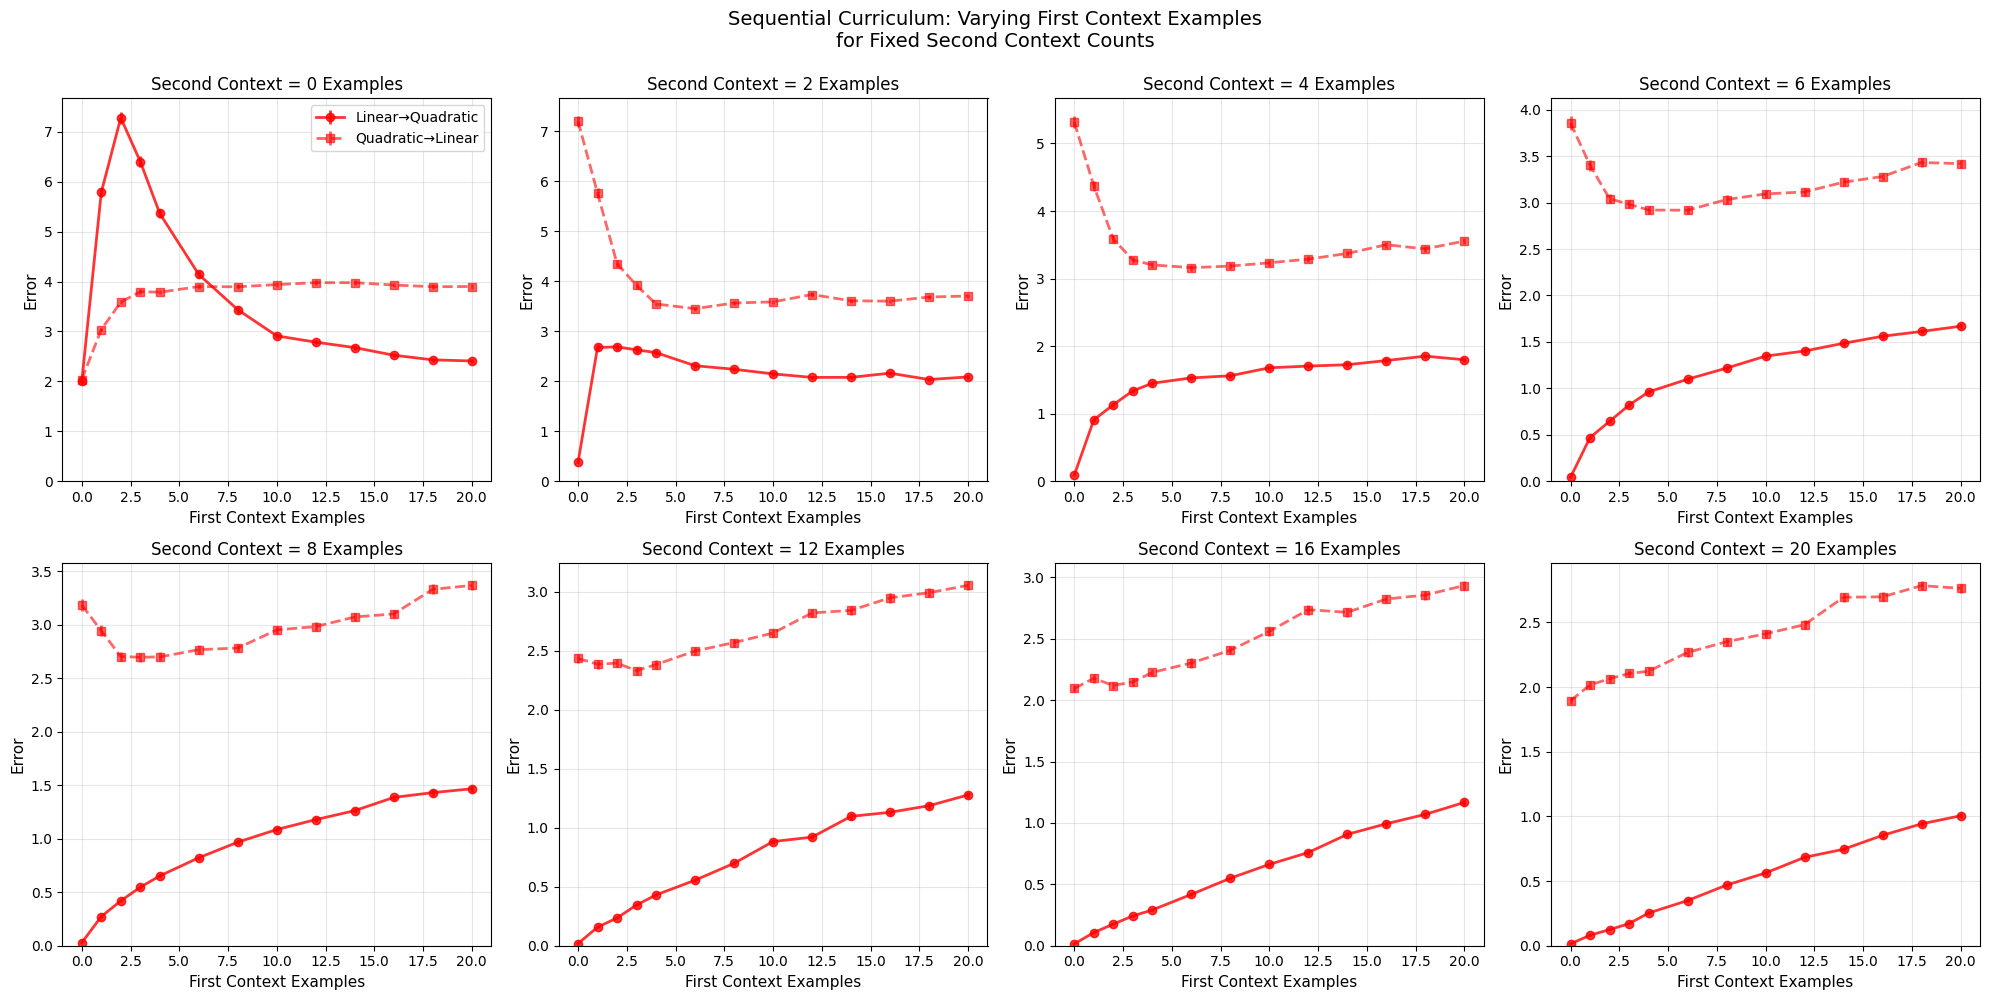

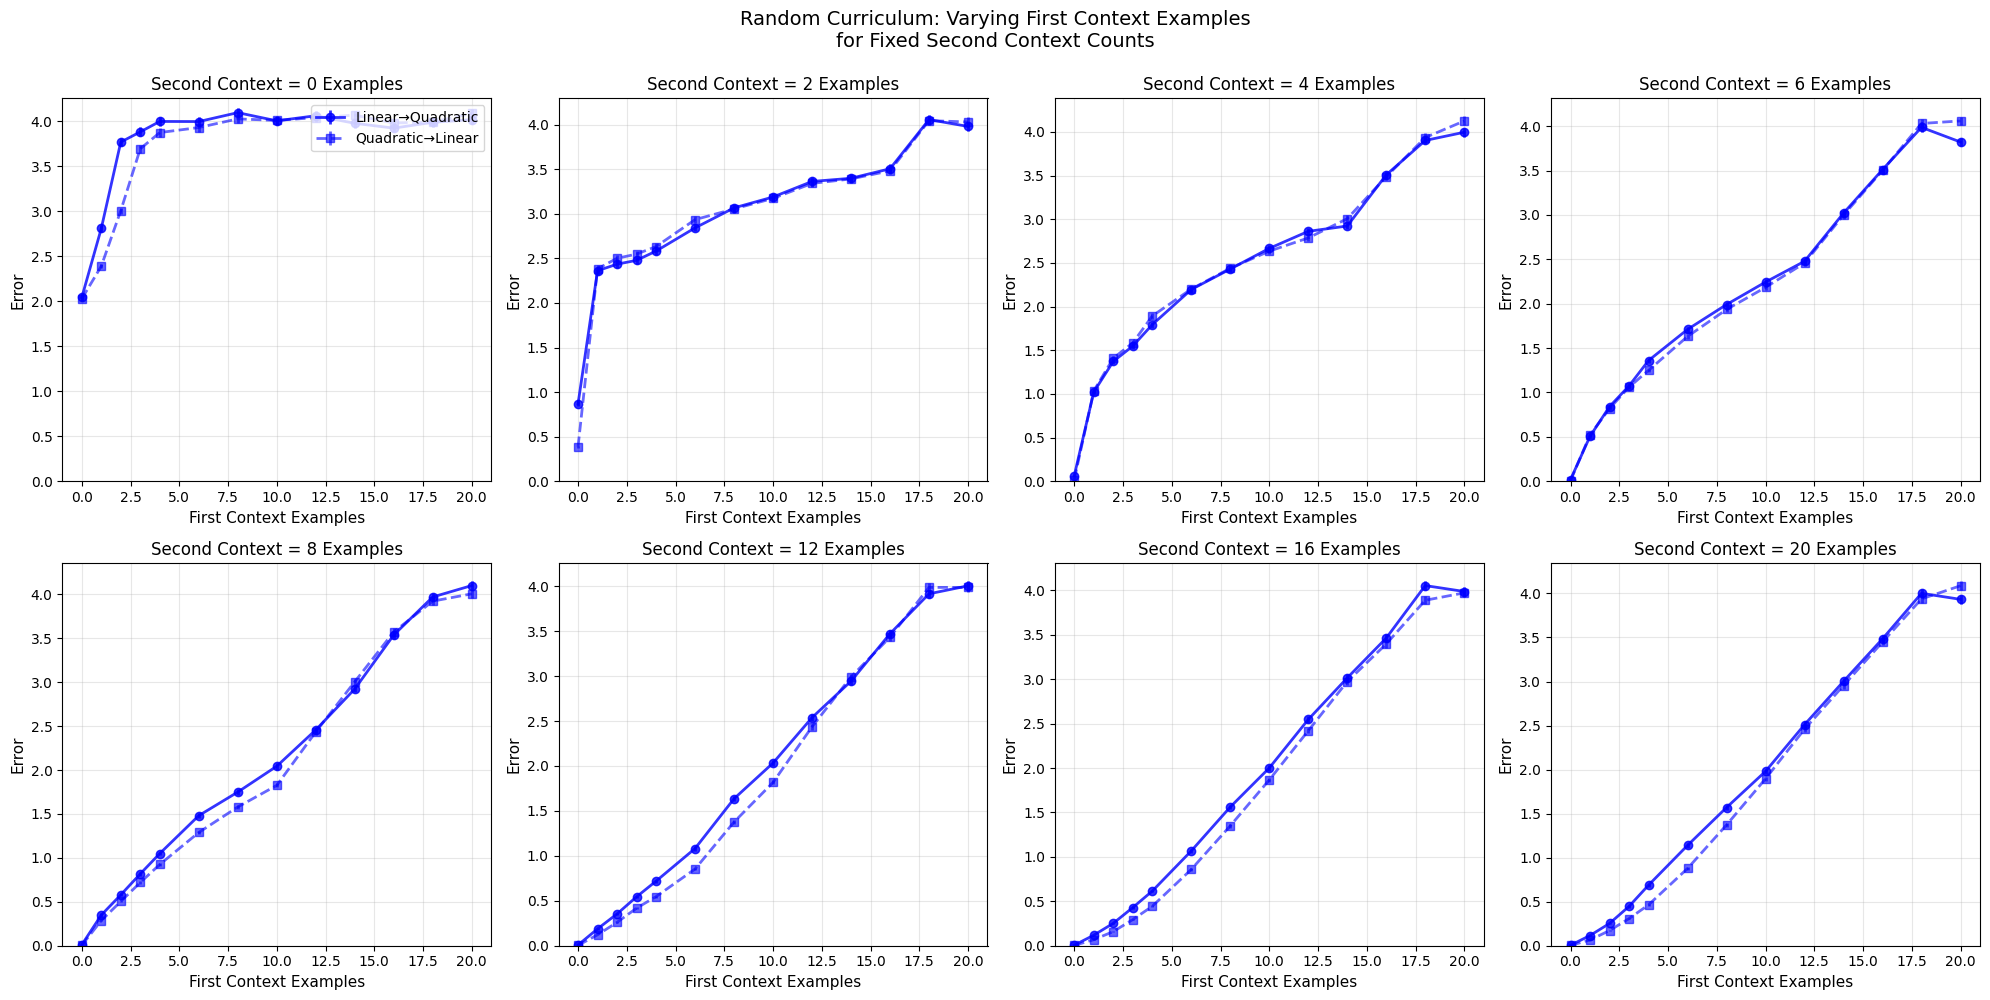

In [34]:
# Figure 4: Compare interference when switching at different points
# Show error as function of first context examples, for fixed second context
# Separate figure for each curriculum

# Get the index/column values (should be same across curricula)
linear_first = linear_to_quad_mixed_mean.index.values
quadratic_second_ltq = linear_to_quad_mixed_mean.columns.values
quadratic_first = quad_to_linear_mixed_mean.index.values
linear_second_qtl = quad_to_linear_mixed_mean.columns.values

# Fixed second context counts - expanded to 8
second_context_counts = [0, 2, 4, 6, 8, 12, 16, 20]

# Create separate figure for each curriculum
curricula = [
    ('Mixed', linear_to_quad_mixed_mean, linear_to_quad_mixed_sem, 
     quad_to_linear_mixed_mean, quad_to_linear_mixed_sem, 'green'),
    ('Sequential', linear_to_quad_sequential_mean, linear_to_quad_sequential_sem,
     quad_to_linear_sequential_mean, quad_to_linear_sequential_sem, 'red'),
    ('Random', linear_to_quad_random_mean, linear_to_quad_random_sem,
     quad_to_linear_random_mean, quad_to_linear_random_sem, 'blue')
]

for curriculum_name, ltq_mean, ltq_sem, qtl_mean, qtl_sem, color in curricula:
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    
    for idx, n_second in enumerate(second_context_counts):
        row = idx // 4
        col = idx % 4
        ax = axes[row, col]
        
        # Linear → Quadratic: second context is QUADRATIC
        if n_second in quadratic_second_ltq:
            ltq_errors = ltq_mean[n_second].values
            ltq_first_context = ltq_mean.index.values
            ltq_sem_vals = ltq_sem[n_second].values
            ax.errorbar(ltq_first_context, ltq_errors, yerr=ltq_sem_vals, 
                       marker='o', label='Linear→Quadratic', linewidth=2, 
                       markersize=6, color=color, alpha=0.8)
        
        # Quadratic → Linear: second context is LINEAR
        if n_second in linear_second_qtl:
            qtl_errors = qtl_mean[n_second].values
            qtl_first_context = qtl_mean.index.values
            qtl_sem_vals = qtl_sem[n_second].values
            ax.errorbar(qtl_first_context, qtl_errors, yerr=qtl_sem_vals, 
                       marker='s', label='Quadratic→Linear', linewidth=2, 
                       markersize=6, color=color, alpha=0.6, linestyle='--')
        
        ax.set_xlabel('First Context Examples', fontsize=11)
        ax.set_ylabel('Error', fontsize=11)
        ax.set_title(f'Second Context = {n_second} Examples', fontsize=12)
        ax.grid(True, alpha=0.3)
        if idx == 0:  # Only show legend on first plot
            ax.legend(fontsize=10, loc='upper right')
        ax.set_ylim(bottom=0)
    
    plt.suptitle(f'{curriculum_name} Curriculum: Varying First Context Examples\n' +
                 'for Fixed Second Context Counts', fontsize=14, y=0.995)
    plt.tight_layout()
    plt.show()


In [3]:
dual_mixed_mean

,linear_0,linear_1,linear_2,linear_3,linear_4,linear_6,linear_8,linear_10,linear_12,linear_14,linear_16,linear_18,linear_20
quadratic_examples,,,,,,,,,,,,,
0,2.033680,1.269578,0.447235,0.107861,0.032293,0.008826,0.005587,0.004241,0.003664,0.003164,0.002950,0.002686,0.002602
1,2.369530,2.848914,2.150247,1.424288,1.020646,0.468746,0.260233,0.151112,0.100494,0.077065,0.060717,0.049928,0.039874
2,2.924746,3.034158,2.365650,1.711654,1.204975,0.712898,0.434830,0.265091,0.198881,0.154728,0.111513,0.098737,0.078148
3,3.487052,3.058372,2.465771,1.875755,1.464215,0.903834,0.572698,0.389513,0.286002,0.216766,0.171795,0.138787,0.115443
4,3.651403,3.073616,2.572927,1.991888,1.569516,1.033710,0.700598,0.496227,0.366858,0.281156,0.223541,0.194612,0.170438
6,3.811787,3.139521,2.670787,2.214368,1.848618,1.275916,0.950803,0.702175,0.548969,0.437325,0.365222,0.302571,0.275782
8,3.827495,3.300583,2.858370,2.409041,2.118162,1.504440,1.178734,0.920814,0.731645,0.598301,0.504353,0.442186,0.399601
10,3.864121,3.366950,2.927881,2.555273,2.254107,1.756213,1.374363,1.163689,0.938459,0.755597,0.656259,0.566986,0.490020
12,3.796291,3.440264,3.130271,2.704367,2.438934,1.998438,1.553853,1.334605,1.101058,0.945699,0.825254,0.741923,0.628716


In [4]:
# Rename columns from 'quadratic_X' to integer X for all dataframes
dataframes = [dual_mixed_mean, dual_mixed_sem, dual_random_mean, 
              dual_random_sem, dual_sequential_mean, dual_sequential_sem]

for df in dataframes:
    rename_dict = {col: int(col.split('_')[1]) for col in df.columns if col.startswith('linear_')}
    df.rename(columns=rename_dict, inplace=True)

In [5]:
dual_mixed_mean

,0,1,2,3,4,6,8,10,12,14,16,18,20
quadratic_examples,,,,,,,,,,,,,
0,2.033680,1.269578,0.447235,0.107861,0.032293,0.008826,0.005587,0.004241,0.003664,0.003164,0.002950,0.002686,0.002602
1,2.369530,2.848914,2.150247,1.424288,1.020646,0.468746,0.260233,0.151112,0.100494,0.077065,0.060717,0.049928,0.039874
2,2.924746,3.034158,2.365650,1.711654,1.204975,0.712898,0.434830,0.265091,0.198881,0.154728,0.111513,0.098737,0.078148
3,3.487052,3.058372,2.465771,1.875755,1.464215,0.903834,0.572698,0.389513,0.286002,0.216766,0.171795,0.138787,0.115443
4,3.651403,3.073616,2.572927,1.991888,1.569516,1.033710,0.700598,0.496227,0.366858,0.281156,0.223541,0.194612,0.170438
6,3.811787,3.139521,2.670787,2.214368,1.848618,1.275916,0.950803,0.702175,0.548969,0.437325,0.365222,0.302571,0.275782
8,3.827495,3.300583,2.858370,2.409041,2.118162,1.504440,1.178734,0.920814,0.731645,0.598301,0.504353,0.442186,0.399601
10,3.864121,3.366950,2.927881,2.555273,2.254107,1.756213,1.374363,1.163689,0.938459,0.755597,0.656259,0.566986,0.490020
12,3.796291,3.440264,3.130271,2.704367,2.438934,1.998438,1.553853,1.334605,1.101058,0.945699,0.825254,0.741923,0.628716


# Graphs to go in the paper

## Figure 1: 3D Plots

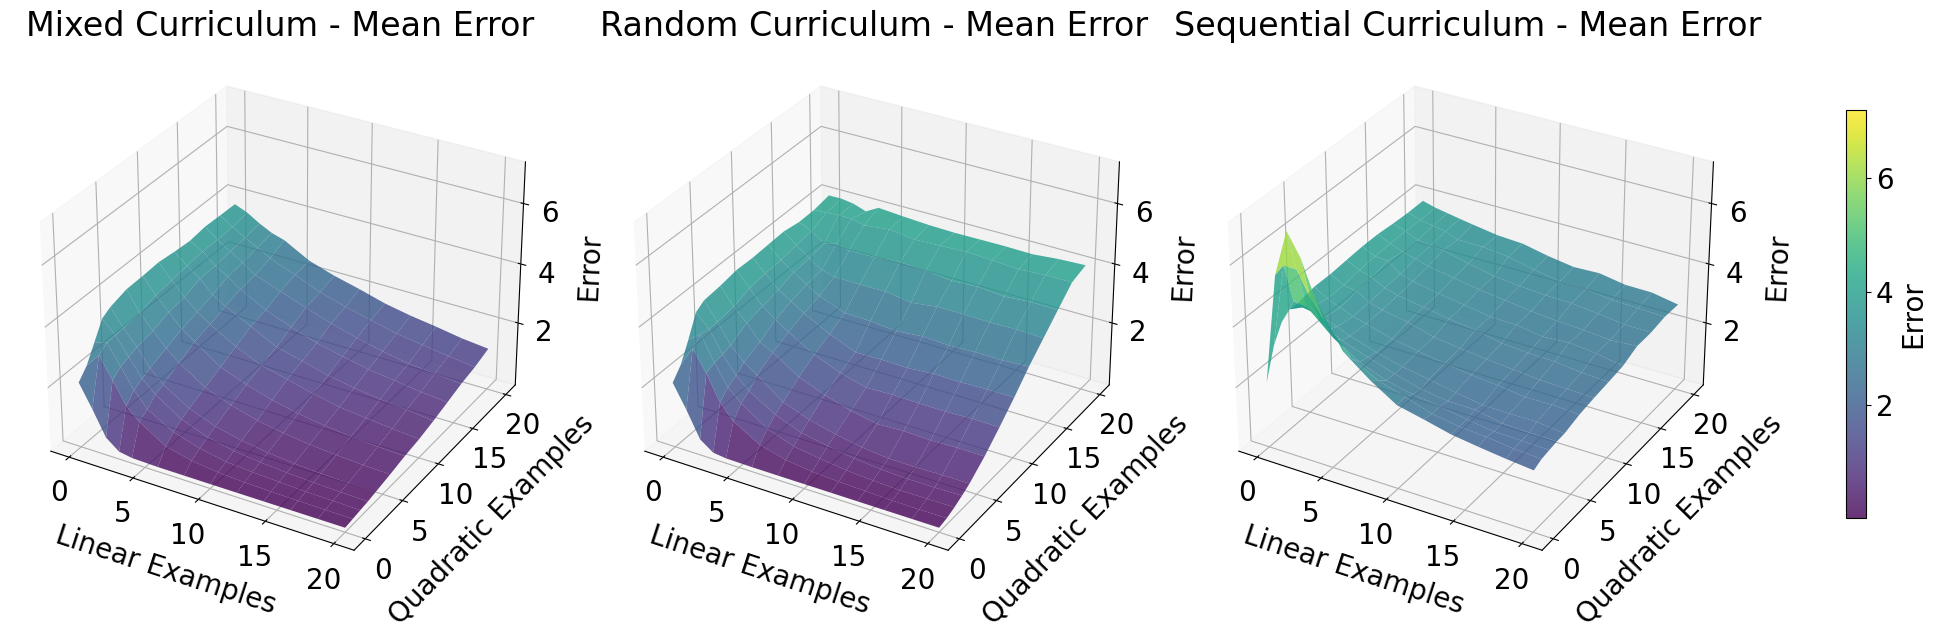

In [19]:
# Plot all 3 surfaces side-by-side with the same z-axis scale and color scale
datasets = [
    (dual_mixed_mean, 'Mixed Curriculum - Mean Error'),
    (dual_random_mean, 'Random Curriculum - Mean Error'),
    (dual_sequential_mean, 'Sequential Curriculum - Mean Error')
]

# First, find the global min and max across all datasets for consistent scaling
all_values = []
for df, _ in datasets:
    all_values.extend(df.values.flatten())
z_min = min(all_values)
z_max = max(all_values)

# Create figure with 3 subplots - larger size to prevent overlap
fig = plt.figure(figsize=(24, 8))

surfaces = []  # Store surfaces for colorbar
for idx, (df, title) in enumerate(datasets):
    # Get the data
    # Rows (index) = Quadratic Examples, Columns = Linear Examples
    quadratic_examples = df.index.values  # Y axis (rows)
    linear_examples = df.columns.values  # X axis (columns)
    
    # Create meshgrid
    X, Y = np.meshgrid(linear_examples, quadratic_examples)
    
    # Get Z values (errors)
    Z = df.values
    
    # Create 3D subplot with spacing
    ax = fig.add_subplot(1, 3, idx + 1, projection='3d')
    
    # Plot surface with consistent color scale (vmin and vmax)
    surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8, edgecolor='none',
                          vmin=z_min, vmax=z_max)
    surfaces.append(surf)
    
    # Set the same z-axis limits for all plots
    ax.set_zlim(z_min, z_max)
    
    # Labels
    ax.set_xlabel('Linear Examples', fontsize=20, labelpad=15)
    ax.set_ylabel('Quadratic Examples', fontsize=20, labelpad=15)
    ax.set_zlabel('Error', fontsize=20, labelpad=10)  # Increased to prevent cutoff
    ax.set_title(title, fontsize=24)
    # Increase tick label sizes
    ax.tick_params(labelsize=20)

# Adjust spacing between subplots - reduced spacing
plt.subplots_adjust(left=0.05, right=0.95, bottom=0.1, top=0.95, wspace=0.1)

# Add a single colorbar on the right side, positioned to not block the Error label
# Attach colorbar to all three subplots so they all shrink equally and stay the same size
cbar = fig.colorbar(surfaces[0], ax=fig.axes, shrink=0.6, aspect=20, pad=0.05)
cbar.set_label('Error', fontsize=20)
cbar.ax.tick_params(labelsize=20)


plt.show()


## Figures 2 and 3: Plotting 3 Dual Training methods against each other

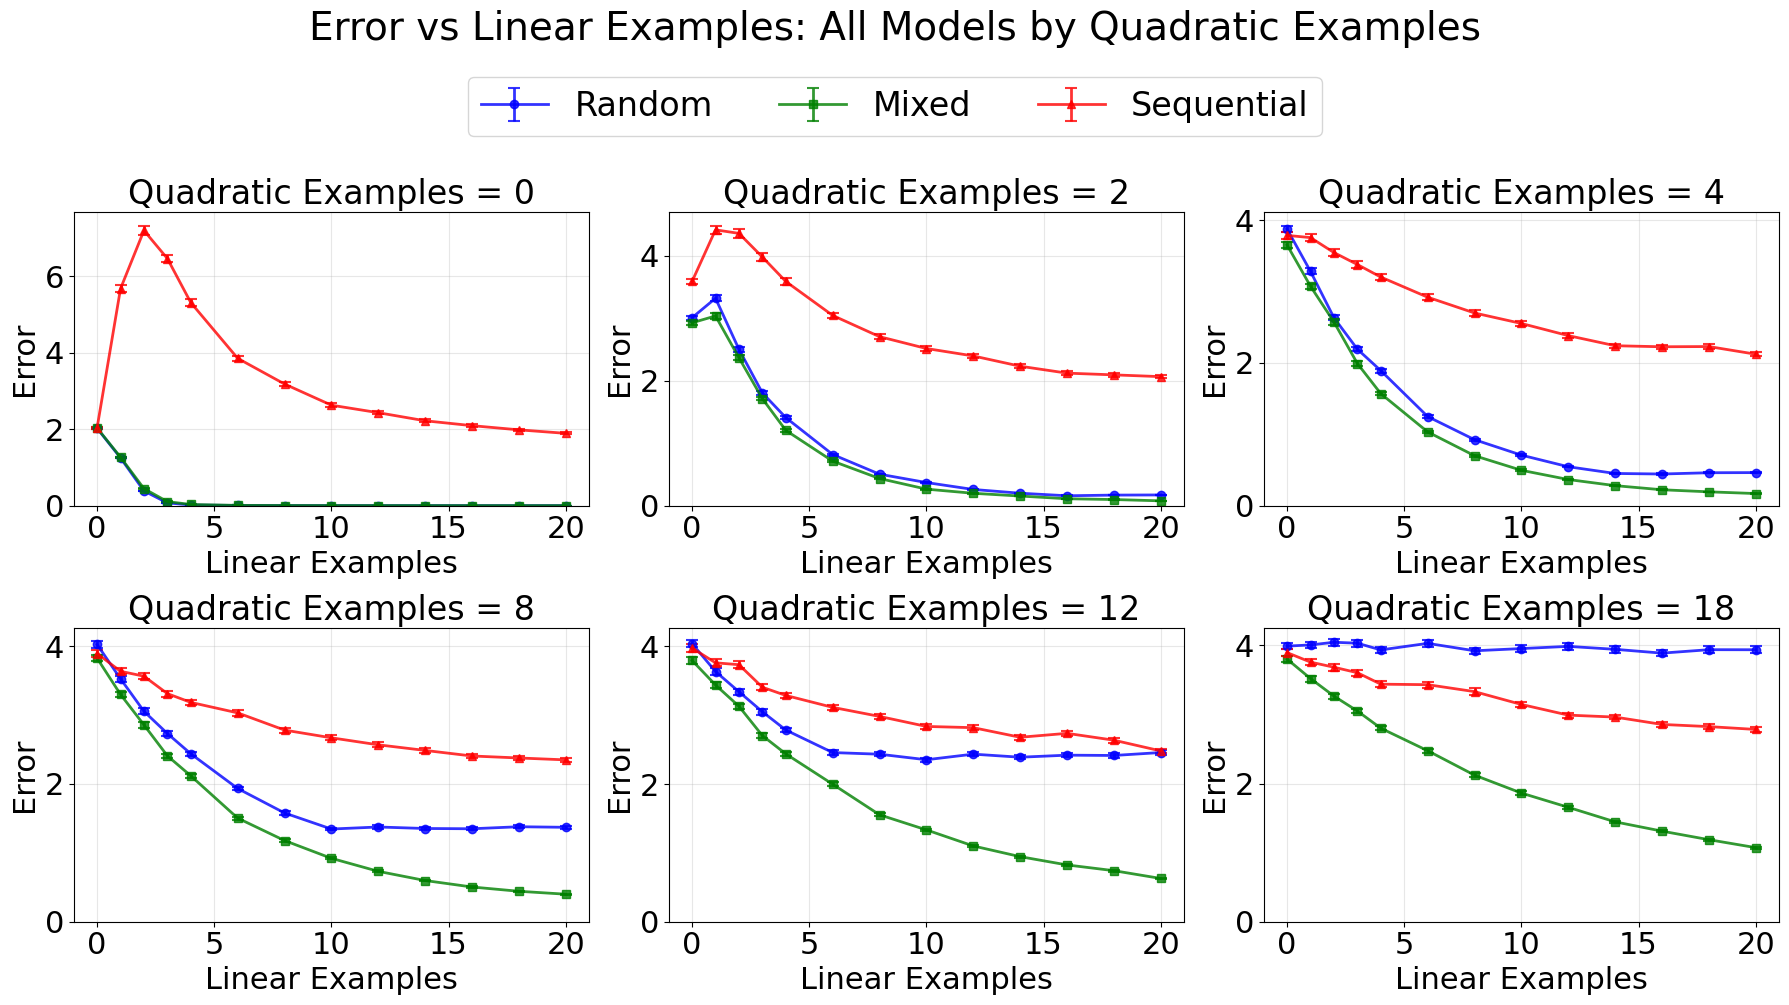

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Plot one graph per linear example count, all three models on each
linear_examples_all = dual_mixed_mean.columns.values  # Columns = Linear Examples
# Filter to only show specific linear example values: 0, 2, 4, 8, 12, 18
linear_examples = [x for x in linear_examples_all if x in [0, 2, 4, 8, 12, 18]]
quadratic_examples = dual_mixed_mean.index.values  # Rows (index) = Quadratic Examples

n_plots = len(linear_examples)
n_cols = 3  # Number of columns in subplot grid
n_rows = (n_plots + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten() if n_plots > 1 else [axes]

# Colors and markers for each model
model_styles = {
    'Random': {'color': 'blue', 'marker': 'o'},
    'Mixed': {'color': 'green', 'marker': 's'},
    'Sequential': {'color': 'red', 'marker': '^'}
}

datasets = [
    (dual_random_mean, dual_random_sem, 'Random'),
    (dual_mixed_mean, dual_mixed_sem, 'Mixed'),
    (dual_sequential_mean, dual_sequential_sem, 'Sequential')
]

for idx, n_linear in enumerate(linear_examples):
    ax = axes[idx]
    
    # Plot all three models on this subplot
    for mean_df, sem_df, model_name in datasets:
        mean_values = mean_df.loc[n_linear].values
        sem_values = sem_df.loc[n_linear].values
        style = model_styles[model_name]
        
        ax.errorbar(quadratic_examples, mean_values, yerr=sem_values, 
                    marker=style['marker'], capsize=4, capthick=1.5, 
                    linewidth=2, markersize=6, label=model_name, 
                    color=style['color'], alpha=0.8)
    
    ax.set_xlabel('Linear Examples', fontsize=22)
    ax.set_ylabel('Error', fontsize=22)
    ax.set_title(f'Quadratic Examples = {n_linear}', fontsize=24)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)
    ax.tick_params(labelsize=22)
    
# Hide unused subplots
for idx in range(n_plots, len(axes)):
    axes[idx].set_visible(False)

# Create a single shared legend below the title
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, fontsize=24, 
           bbox_to_anchor=(0.5, 0.95), frameon=True)

plt.suptitle('Error vs Linear Examples: All Models by Quadratic Examples', 
             fontsize=28, y=1.0)
plt.tight_layout(rect=[0, 0, 1, 0.90])  # Leave space at top for legend and title
plt.show()

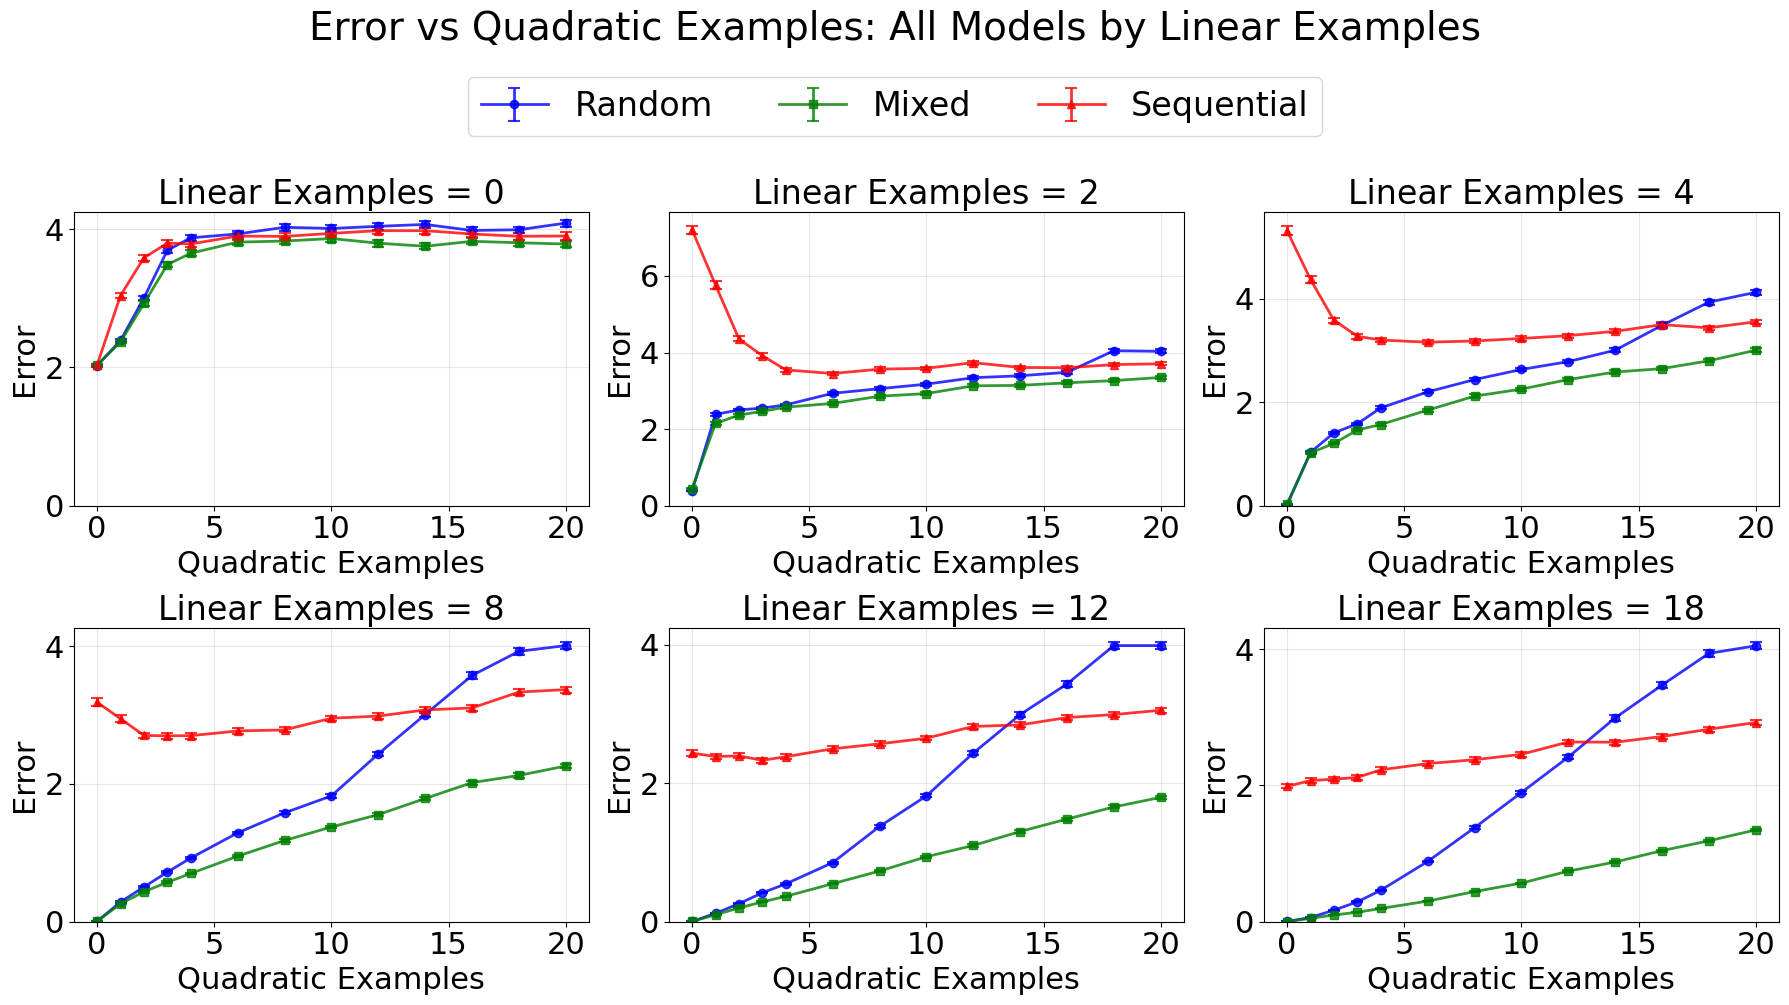

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Plot one graph per quadratic example count, all three models on each
linear_examples = dual_mixed_mean.columns.values  # Columns = Linear Examples
# Filter to only show specific quadratic example values: 2, 4, 6, 8, 12, 18
quadratic_examples_all = dual_mixed_mean.columns.values
quadratic_examples = [x for x in quadratic_examples_all if x in [0, 2, 4, 8, 12, 18]]


n_plots = len(quadratic_examples)
n_cols = 3  # Number of columns in subplot grid
n_rows = (n_plots + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten() if n_plots > 1 else [axes]

# Colors and markers for each model
model_styles = {
    'Random': {'color': 'blue', 'marker': 'o'},
    'Mixed': {'color': 'green', 'marker': 's'},
    'Sequential': {'color': 'red', 'marker': '^'}
}

datasets = [
    (dual_random_mean, dual_random_sem, 'Random'),
    (dual_mixed_mean, dual_mixed_sem, 'Mixed'),
    (dual_sequential_mean, dual_sequential_sem, 'Sequential')
]

for idx, n_quadratic in enumerate(quadratic_examples):
    ax = axes[idx]
    
    # Plot all three models on this subplot
    for mean_df, sem_df, model_name in datasets:
        mean_values = mean_df[n_quadratic].values
        sem_values = sem_df[n_quadratic].values
        style = model_styles[model_name]
        
        ax.errorbar(linear_examples, mean_values, yerr=sem_values, 
                    marker=style['marker'], capsize=4, capthick=1.5, 
                    linewidth=2, markersize=6, label=model_name, 
                    color=style['color'], alpha=0.8)
    
    ax.set_xlabel('Quadratic Examples', fontsize=22)
    ax.set_ylabel('Error', fontsize=22)
    ax.set_title(f'Linear Examples = {n_quadratic}', fontsize=24)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)
    ax.tick_params(labelsize=22)
    
# Hide unused subplots
for idx in range(n_plots, len(axes)):
    axes[idx].set_visible(False)

# Create a single shared legend below the title
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, fontsize=24, 
           bbox_to_anchor=(0.5, 0.95), frameon=True)

plt.suptitle('Error vs Quadratic Examples: All Models by Linear Examples', 
             fontsize=28, y=1.0)
plt.tight_layout(rect=[0, 0, 1, 0.90])  # Leave space at top for legend and title
plt.show()


## Figures 4 and 5: Dual Sequential Plots

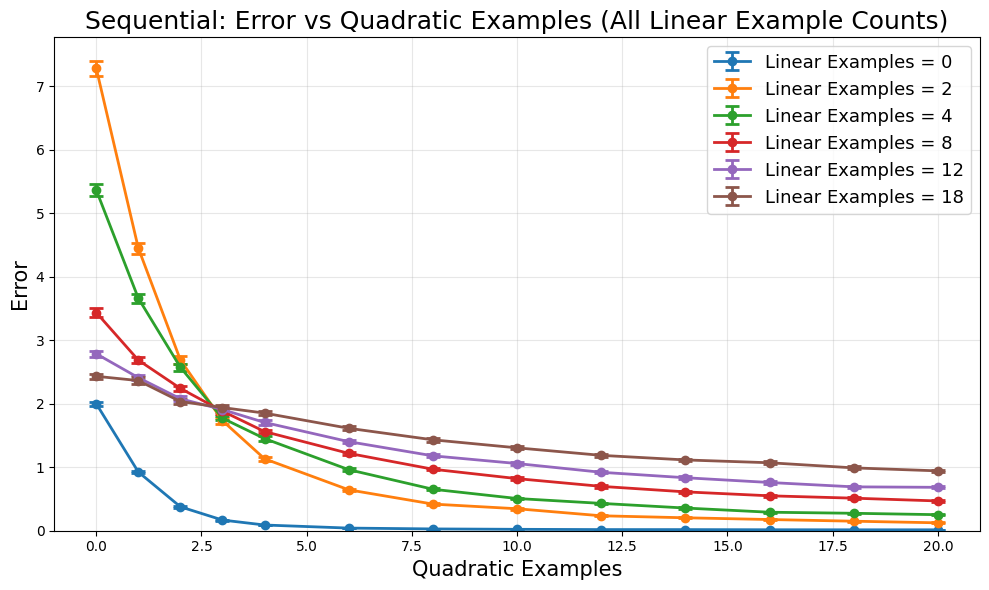

In [71]:
# Plot one graph per linear example count, all three models on each
linear_examples_all = dual_mixed_mean.columns.values  # Columns = Linear Examples
# Filter to only show specific linear example values: 0, 2, 4, 8, 12, 18
linear_examples = [x for x in linear_examples_all if x in [0, 2, 4, 8, 12, 18]]
quadratic_examples = dual_mixed_mean.index.values  # Rows (index) = Quadratic Examples

fig, ax = plt.subplots(figsize=(10, 6))

# Plot all lines for dual sequential, one for each linear example count
for n_linear in linear_examples:
    mean_values = dual_sequential_mean.loc[n_linear].values
    sem_values = dual_sequential_sem.loc[n_linear].values
    
    ax.errorbar(quadratic_examples, mean_values, yerr=sem_values, 
                marker='o', capsize=5, capthick=2, linewidth=2, markersize=6,
                label=f'Linear Examples = {n_linear}')

ax.set_xlabel('Linear Examples', fontsize=15)
ax.set_ylabel('Error', fontsize=15)
ax.set_title('Sequential: Error vs Quadratic Examples (All Linear Example Counts)', 
             fontsize=18)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)  # Start y-axis at 0
ax.legend(fontsize=13)

plt.tight_layout()
plt.show()


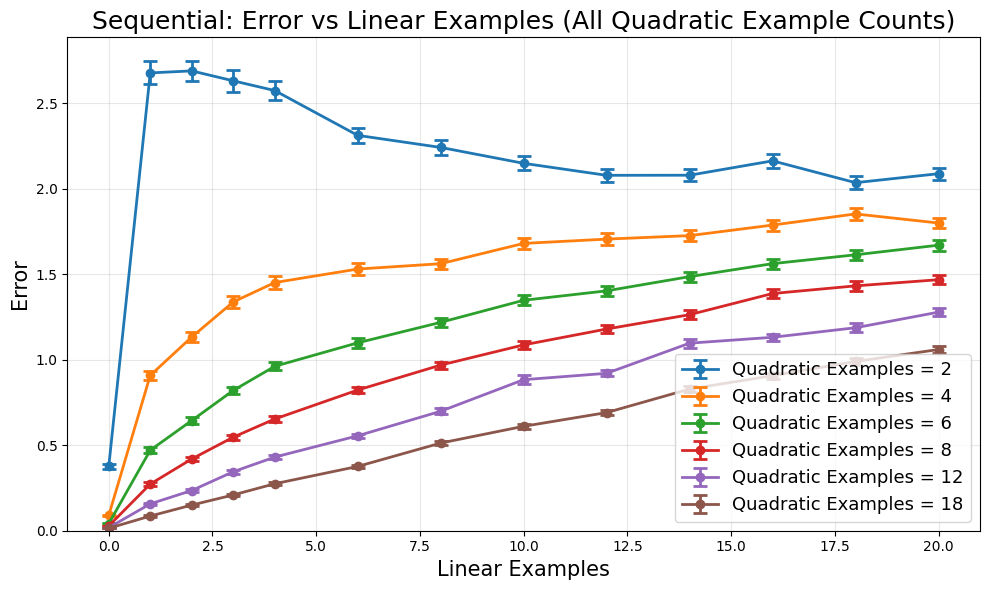

In [72]:
# Plot one graph per quadratic example count, all three models on each
linear_examples = dual_mixed_mean.columns.values  # Columns = Linear Examples
# Filter to only show specific quadratic example values: 2, 4, 6, 8, 12, 18
quadratic_examples_all = dual_mixed_mean.columns.values
quadratic_examples = [x for x in quadratic_examples_all if x in [2, 4, 6, 8, 12, 18]]

fig, ax = plt.subplots(figsize=(10, 6))

# Plot all lines for dual sequential, one for each quadratic example count
for n_quadratic in quadratic_examples:
    mean_values = dual_sequential_mean[n_quadratic].values
    sem_values = dual_sequential_sem[n_quadratic].values
    
    ax.errorbar(linear_examples, mean_values, yerr=sem_values, 
                marker='o', capsize=5, capthick=2, linewidth=2, markersize=6,
                label=f'Quadratic Examples = {n_quadratic}')

ax.set_xlabel('Linear Examples', fontsize=15)
ax.set_ylabel('Error', fontsize=15)
ax.set_title('Sequential: Error vs Linear Examples (All Quadratic Example Counts)', 
             fontsize=18)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)  # Start y-axis at 0
ax.legend(fontsize=13)

plt.tight_layout()
plt.show()


# Playground

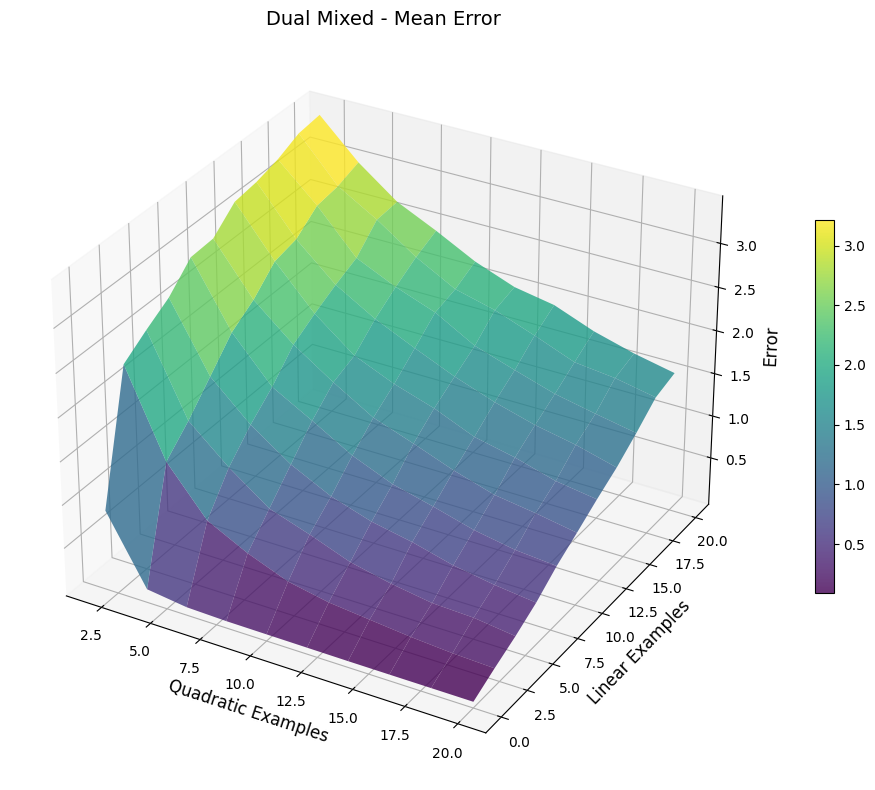

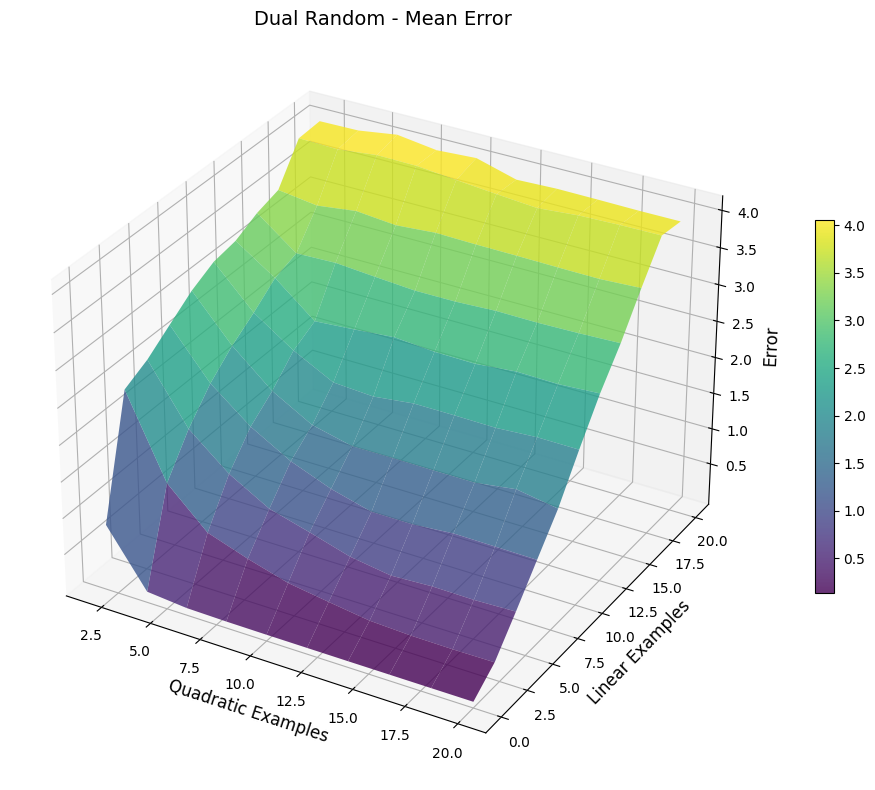

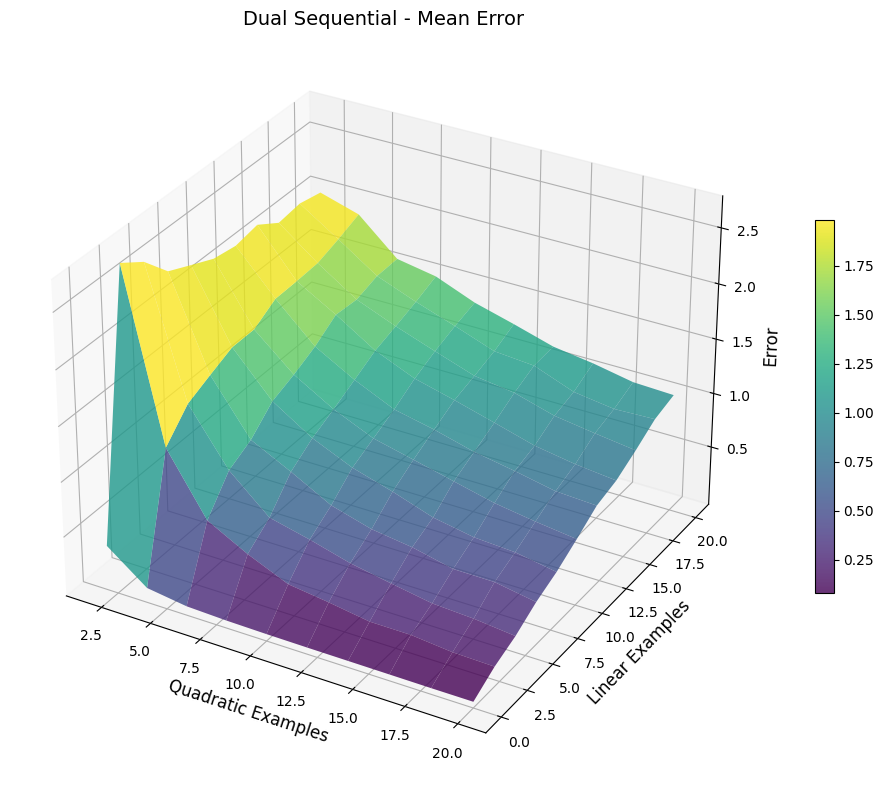

In [59]:

def plot_3d_surface(df, title='3D Error Surface'):
    """
    Plot a 3D surface where:
    - X axis = quadratic examples (column names)
    - Y axis = linear examples (row index)
    - Z axis = error values
    """
    # Get the data
    # Get the data
    # Rows (index) = Quadratic Examples, Columns = Linear Examples
    quadratic_examples = df.index.values  # Y axis (rows)
    linear_examples = df.columns.values  # X axis (columns)
    
    # Create meshgrid
    X, Y = np.meshgrid(linear_examples, quadratic_examples)
    
    # Get Z values (errors)
    Z = df.values
    
    # Create figure and 3D axis
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot surface
    surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8, edgecolor='none')
    
    # Labels
    ax.set_xlabel('Linear Examples', fontsize=12)
    ax.set_ylabel('Quadratic Examples', fontsize=12)
    ax.set_zlabel('Error', fontsize=12)
    ax.set_title(title, fontsize=14)
    
    # Add colorbar
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=20)
    
    plt.tight_layout()
    plt.show()

# Plot for each dataframe
plot_3d_surface(dual_mixed_mean, 'Dual Mixed - Mean Error')
plot_3d_surface(dual_random_mean, 'Dual Random - Mean Error')
plot_3d_surface(dual_sequential_mean, 'Dual Sequential - Mean Error')

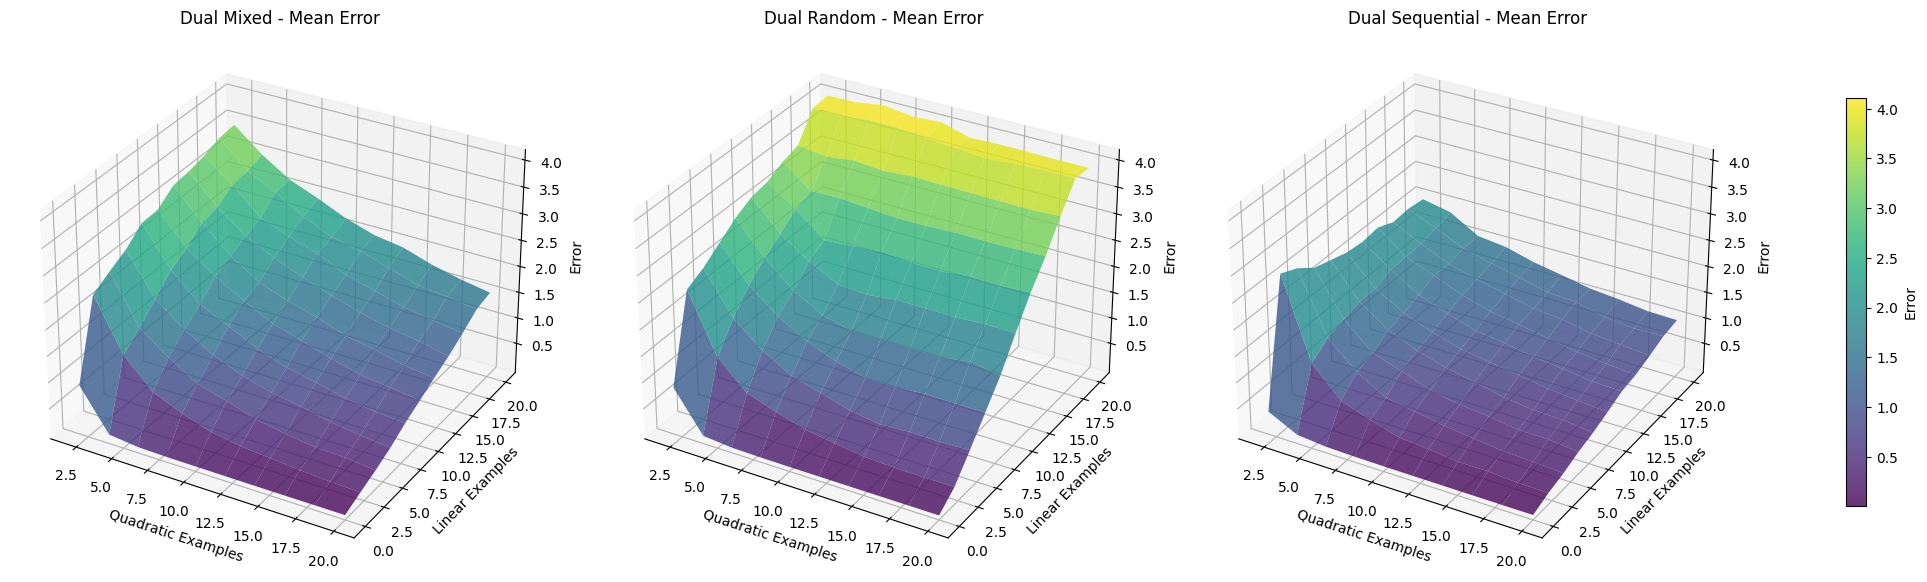

In [60]:
# Plot all 3 surfaces side-by-side with the same z-axis scale and color scale
datasets = [
    (dual_mixed_mean, 'Dual Mixed - Mean Error'),
    (dual_random_mean, 'Dual Random - Mean Error'),
    (dual_sequential_mean, 'Dual Sequential - Mean Error')
]

# First, find the global min and max across all datasets for consistent scaling
all_values = []
for df, _ in datasets:
    all_values.extend(df.values.flatten())
z_min = min(all_values)
z_max = max(all_values)

# Create figure with 3 subplots - larger size to prevent overlap
fig = plt.figure(figsize=(24, 8))

surfaces = []  # Store surfaces for colorbar
for idx, (df, title) in enumerate(datasets):
    # Get the data
    # Get the data
    # Rows (index) = Quadratic Examples, Columns = Linear Examples
    quadratic_examples = df.index.values  # Y axis (rows)
    linear_examples = df.columns.values  # X axis (columns)
    
    # Create meshgrid
    X, Y = np.meshgrid(linear_examples, quadratic_examples)
    
    # Get Z values (errors)
    Z = df.values
    
    # Create 3D subplot with spacing
    ax = fig.add_subplot(1, 3, idx + 1, projection='3d')
    
    # Plot surface with consistent color scale (vmin and vmax)
    surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8, edgecolor='none',
                          vmin=z_min, vmax=z_max)
    surfaces.append(surf)
    
    # Set the same z-axis limits for all plots
    ax.set_zlim(z_min, z_max)
    
    # Labels
    ax.set_xlabel('Linear Examples', fontsize=10)
    ax.set_ylabel('Quadratic Examples', fontsize=10)
    ax.set_zlabel('Error', fontsize=10)
    ax.set_title(title, fontsize=12)

# Adjust spacing between subplots - reduced spacing
plt.subplots_adjust(left=0.05, right=0.95, bottom=0.1, top=0.95, wspace=0.1)

# Add a single colorbar on the right side, positioned to not block the Error label
# Attach colorbar to all three subplots so they all shrink equally and stay the same size
cbar = fig.colorbar(surfaces[0], ax=fig.axes, shrink=0.6, aspect=20, pad=0.05)
cbar.set_label('Error', fontsize=10)

plt.show()


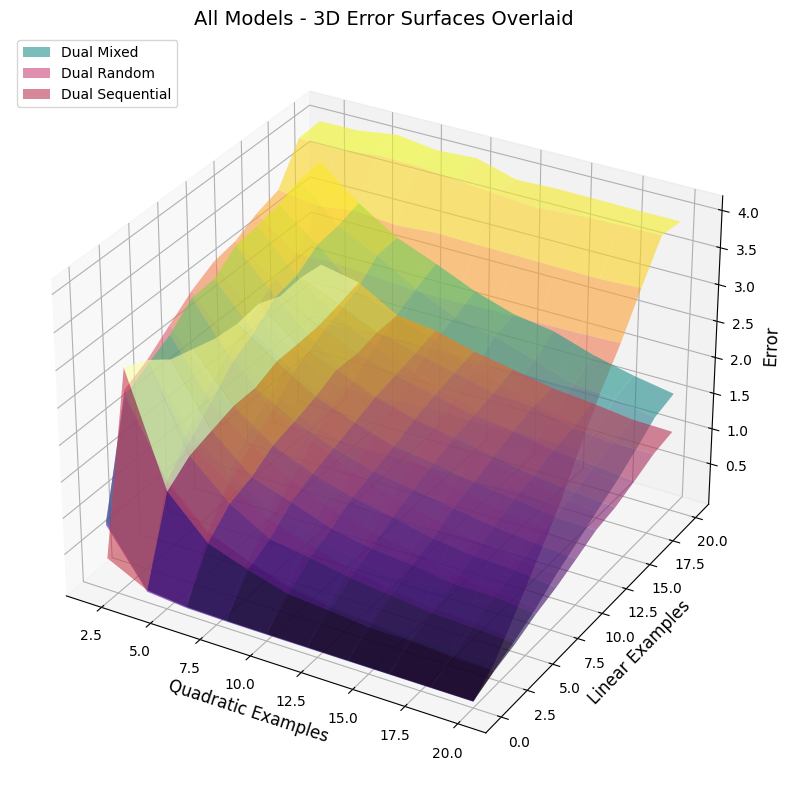

In [61]:
# Plot all 3 surfaces on the same 3D graph
datasets = [
    (dual_mixed_mean, 'Dual Mixed', 'viridis', 0.6),
    (dual_random_mean, 'Dual Random', 'plasma', 0.6),
    (dual_sequential_mean, 'Dual Sequential', 'inferno', 0.6)
]

# Get common axes (assuming all have same structure)
linear_examples = dual_mixed_mean.columns.values  # Columns = Linear Examples
quadratic_examples = dual_mixed_mean.index.values  # Rows (index) = Quadratic Examples
X, Y = np.meshgrid(quadratic_examples, linear_examples)

# Find global min and max for z-axis scaling
all_values = []
for df, _, _, _ in datasets:
    all_values.extend(df.values.flatten())
z_min = min(all_values)
z_max = max(all_values)

# Create single 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot all surfaces
surfaces = []
for df, name, cmap, alpha in datasets:
    Z = df.values
    surf = ax.plot_surface(X, Y, Z, cmap=cmap, alpha=alpha, 
                          edgecolor='none', label=name)
    surfaces.append((surf, name))

# Set consistent z-axis limits
ax.set_zlim(z_min, z_max)

# Labels
ax.set_xlabel('Linear Examples', fontsize=12)
ax.set_ylabel('Quadratic Examples', fontsize=12)
ax.set_zlabel('Error', fontsize=12)
ax.set_title('All Models - 3D Error Surfaces Overlaid', fontsize=14)

# Create a custom legend (matplotlib doesn't support legends for 3D surfaces directly)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=plt.cm.viridis(0.5), alpha=0.6, label='Dual Mixed'),
                  Patch(facecolor=plt.cm.plasma(0.5), alpha=0.6, label='Dual Random'),
                  Patch(facecolor=plt.cm.inferno(0.5), alpha=0.6, label='Dual Sequential')]
ax.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()


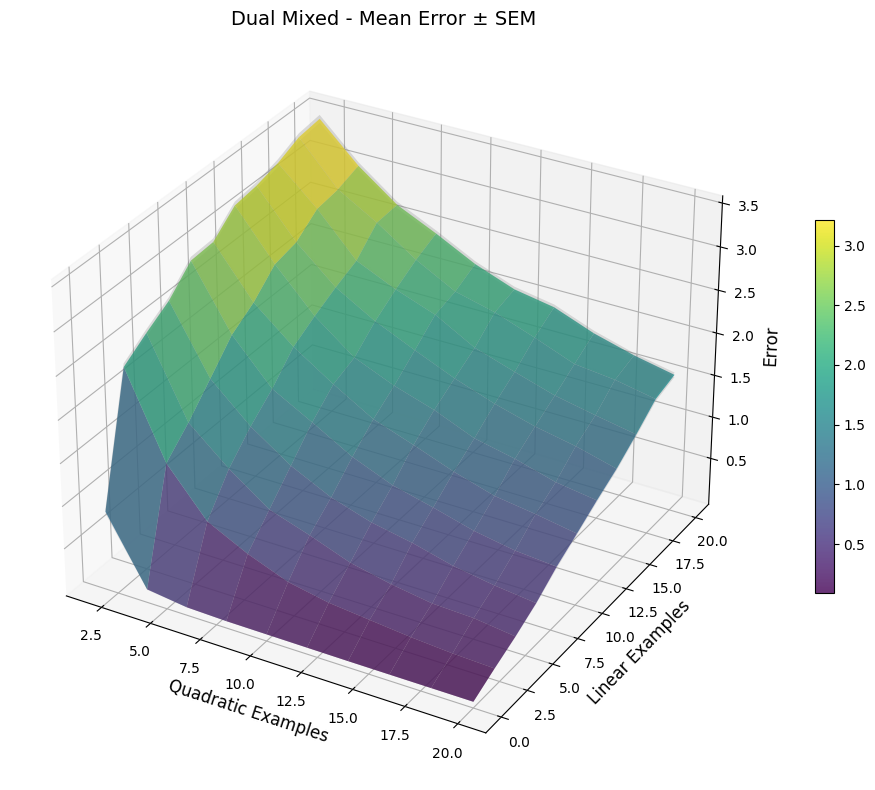

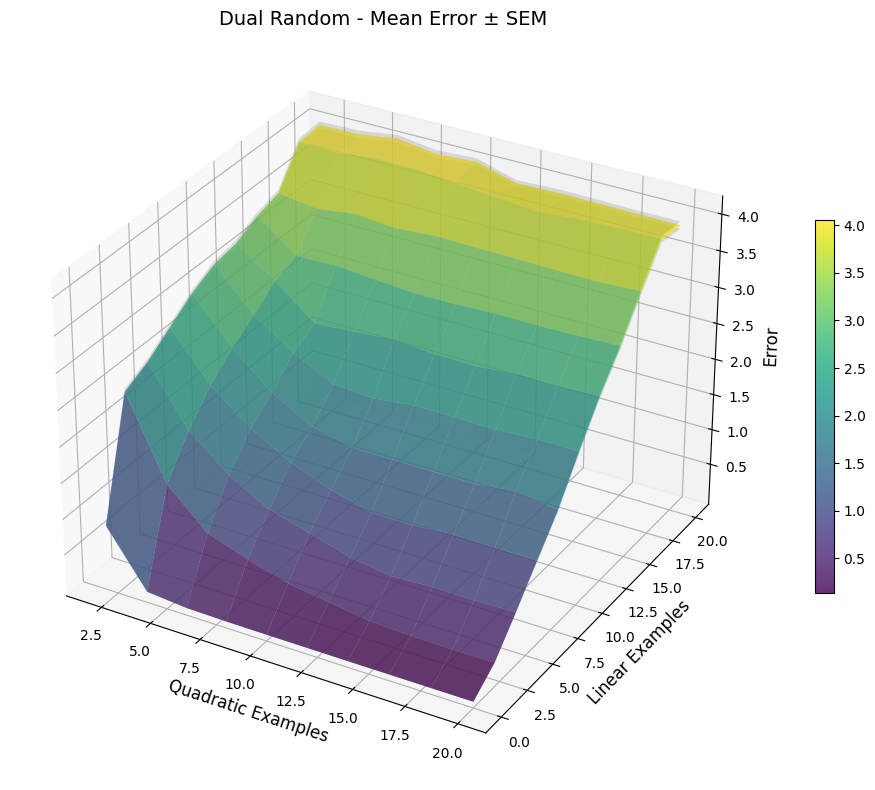

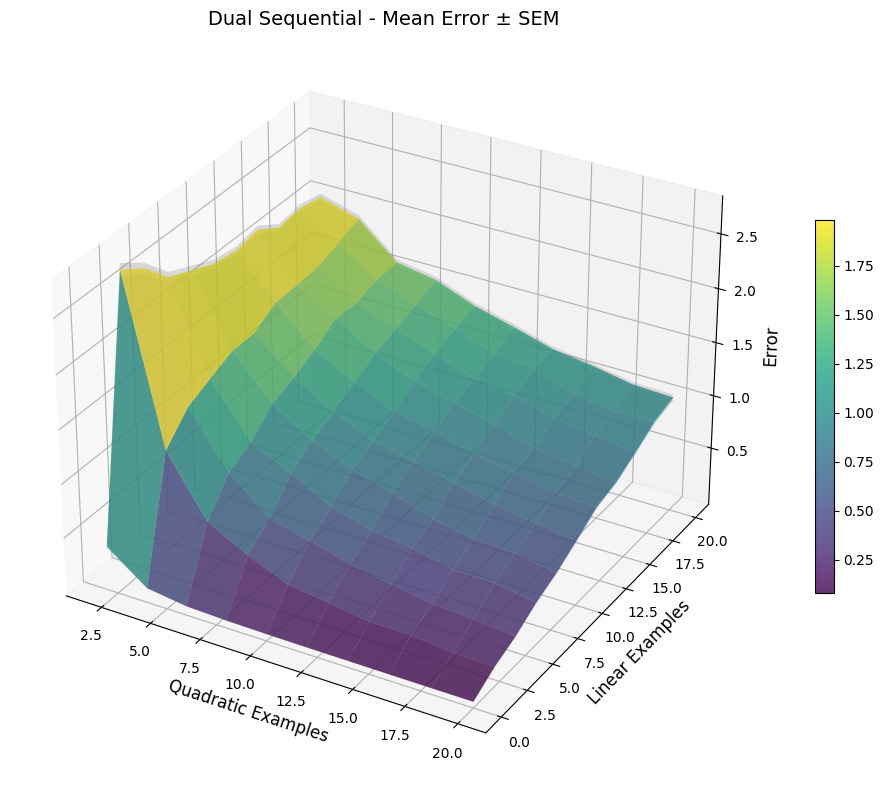

In [62]:
def plot_3d_surface_with_error(mean_df, sem_df, title='3D Error Surface with Error Bars'):
    """
    Plot a 3D surface with error bars where:
    - X axis = quadratic examples (column names)
    - Y axis = linear examples (row index)
    - Z axis = error values
    - Error surfaces show mean ± SEM
    """
    # Get the data
    quadratic_examples = mean_df.index.values  # Y axis
    linear_examples = mean_df.columns.values  # X axis
    
    # Create meshgrid
    X, Y = np.meshgrid(linear_examples, quadratic_examples)
    
    # Get Z values
    Z_mean = mean_df.values
    Z_sem = sem_df.values
    
    # Calculate upper and lower bounds
    Z_upper = Z_mean + Z_sem
    Z_lower = Z_mean - Z_sem
    
    # Create figure and 3D axis
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot error surfaces (upper and lower bounds) with transparency
    ax.plot_surface(X, Y, Z_upper, alpha=0.2, color='gray', label='Mean + SEM')
    ax.plot_surface(X, Y, Z_lower, alpha=0.2, color='gray', label='Mean - SEM')
    
    # Plot main surface (mean)
    surf = ax.plot_surface(X, Y, Z_mean, cmap='viridis', alpha=0.8, edgecolor='none')
    
    # Labels
    ax.set_xlabel('Linear Examples', fontsize=12)
    ax.set_ylabel('Quadratic Examples', fontsize=12)
    ax.set_zlabel('Error', fontsize=12)
    ax.set_title(title, fontsize=14)
    
    # Add colorbar
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=20)
    
    plt.tight_layout()
    plt.show()

# Plot for each pair
plot_3d_surface_with_error(dual_mixed_mean, dual_mixed_sem, 'Dual Mixed - Mean Error ± SEM')
plot_3d_surface_with_error(dual_random_mean, dual_random_sem, 'Dual Random - Mean Error ± SEM')
plot_3d_surface_with_error(dual_sequential_mean, dual_sequential_sem, 'Dual Sequential - Mean Error ± SEM')

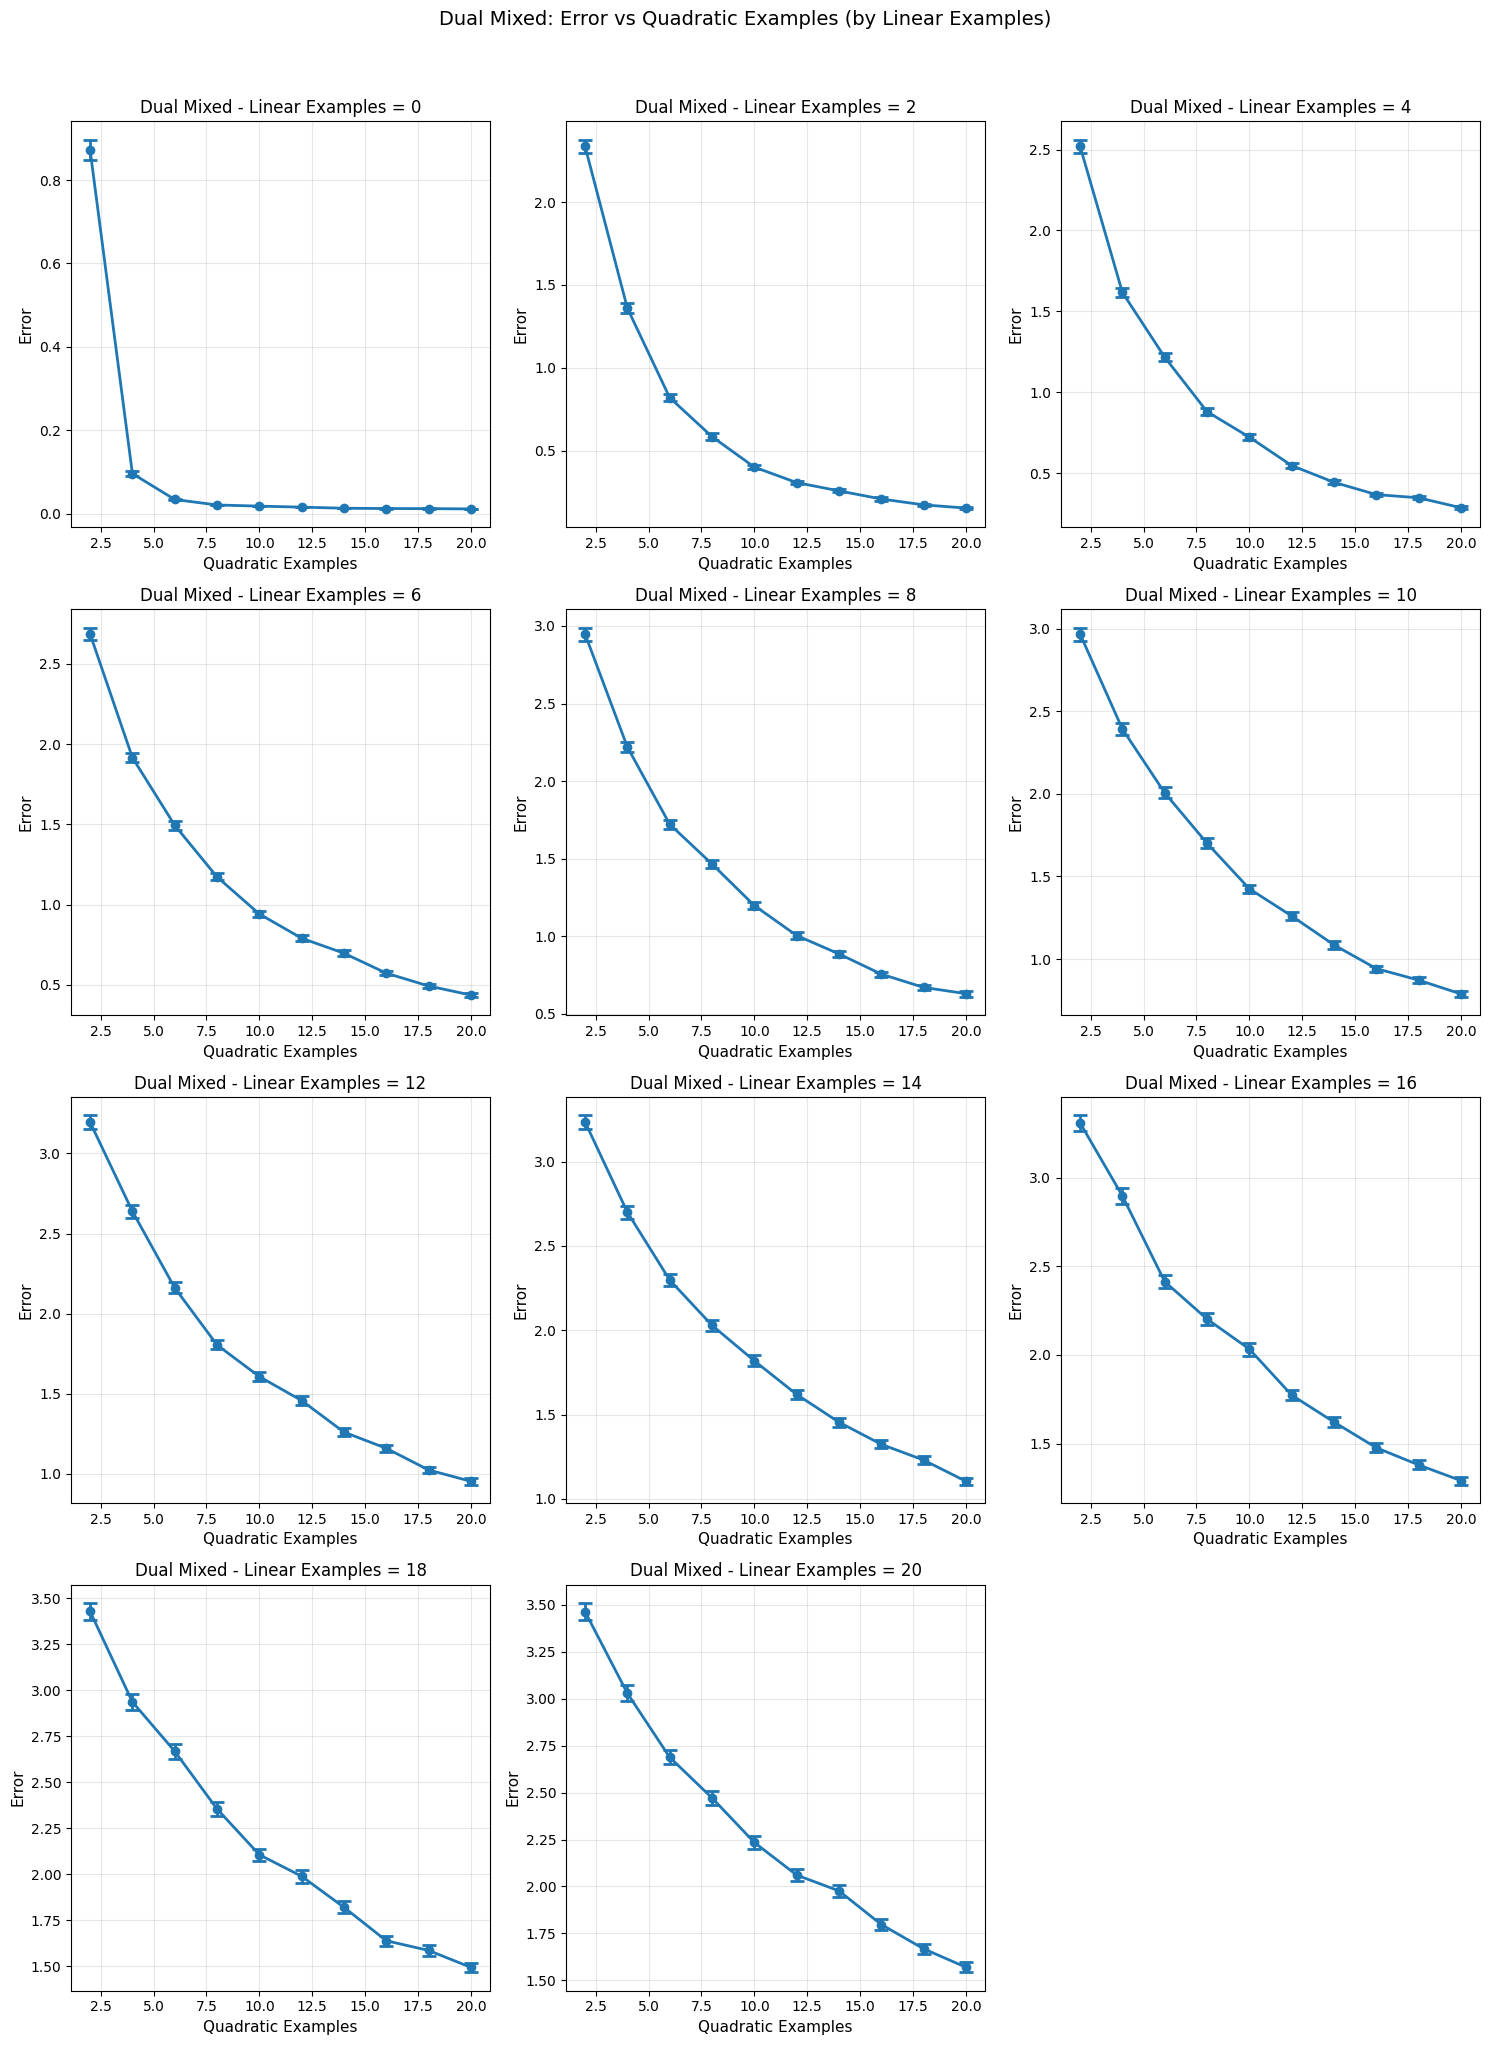

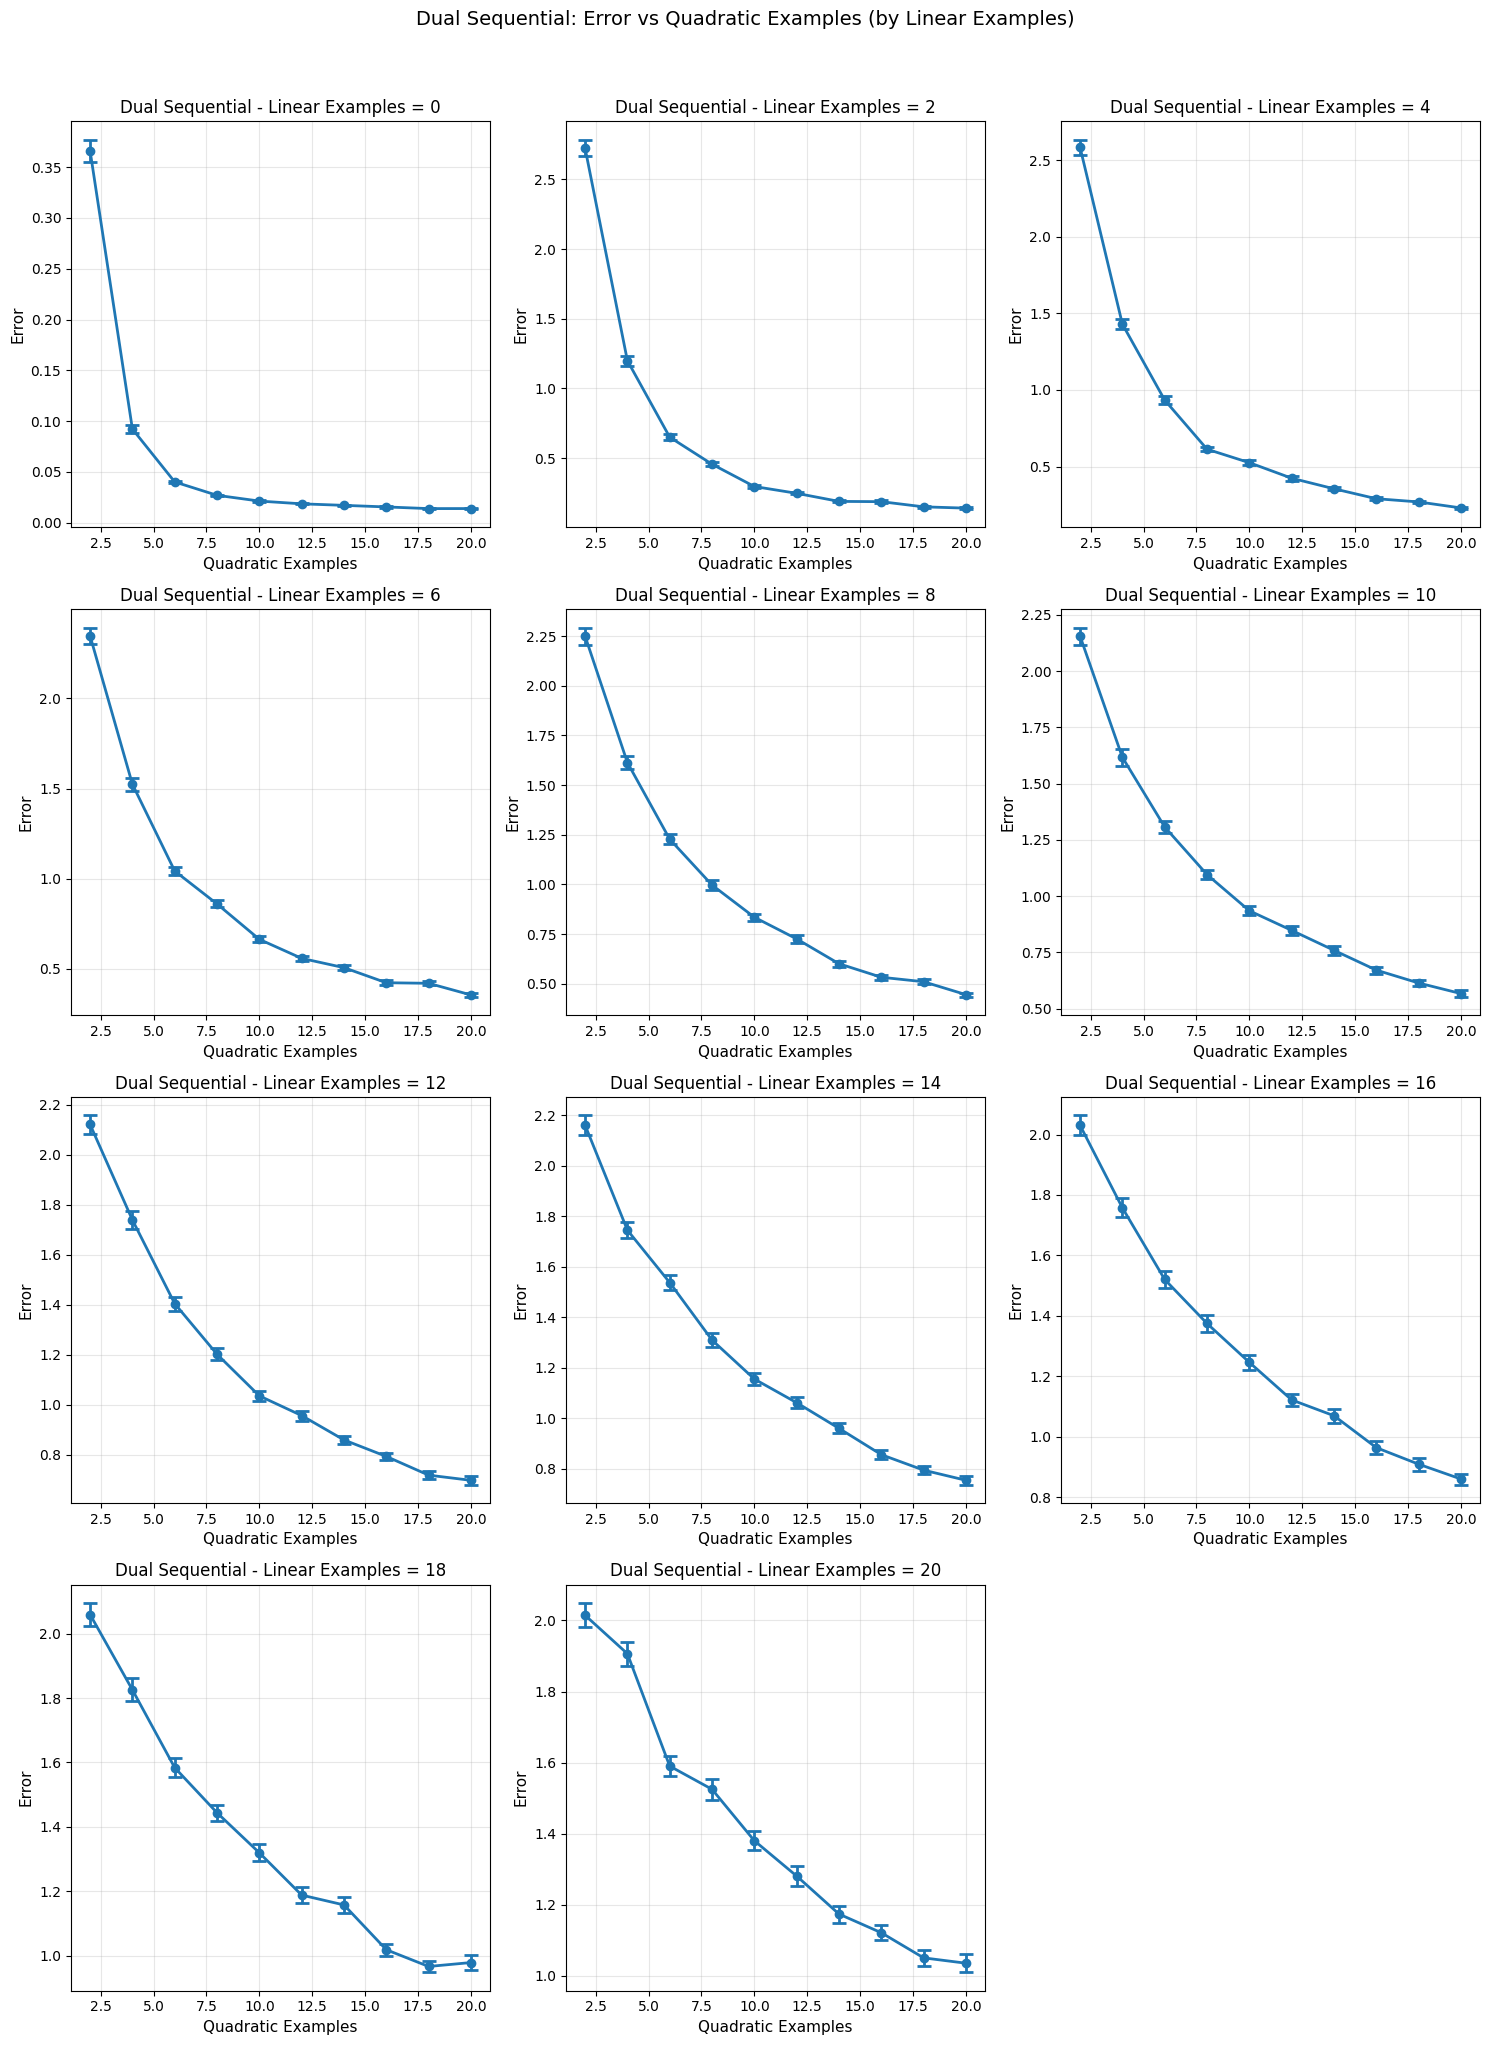

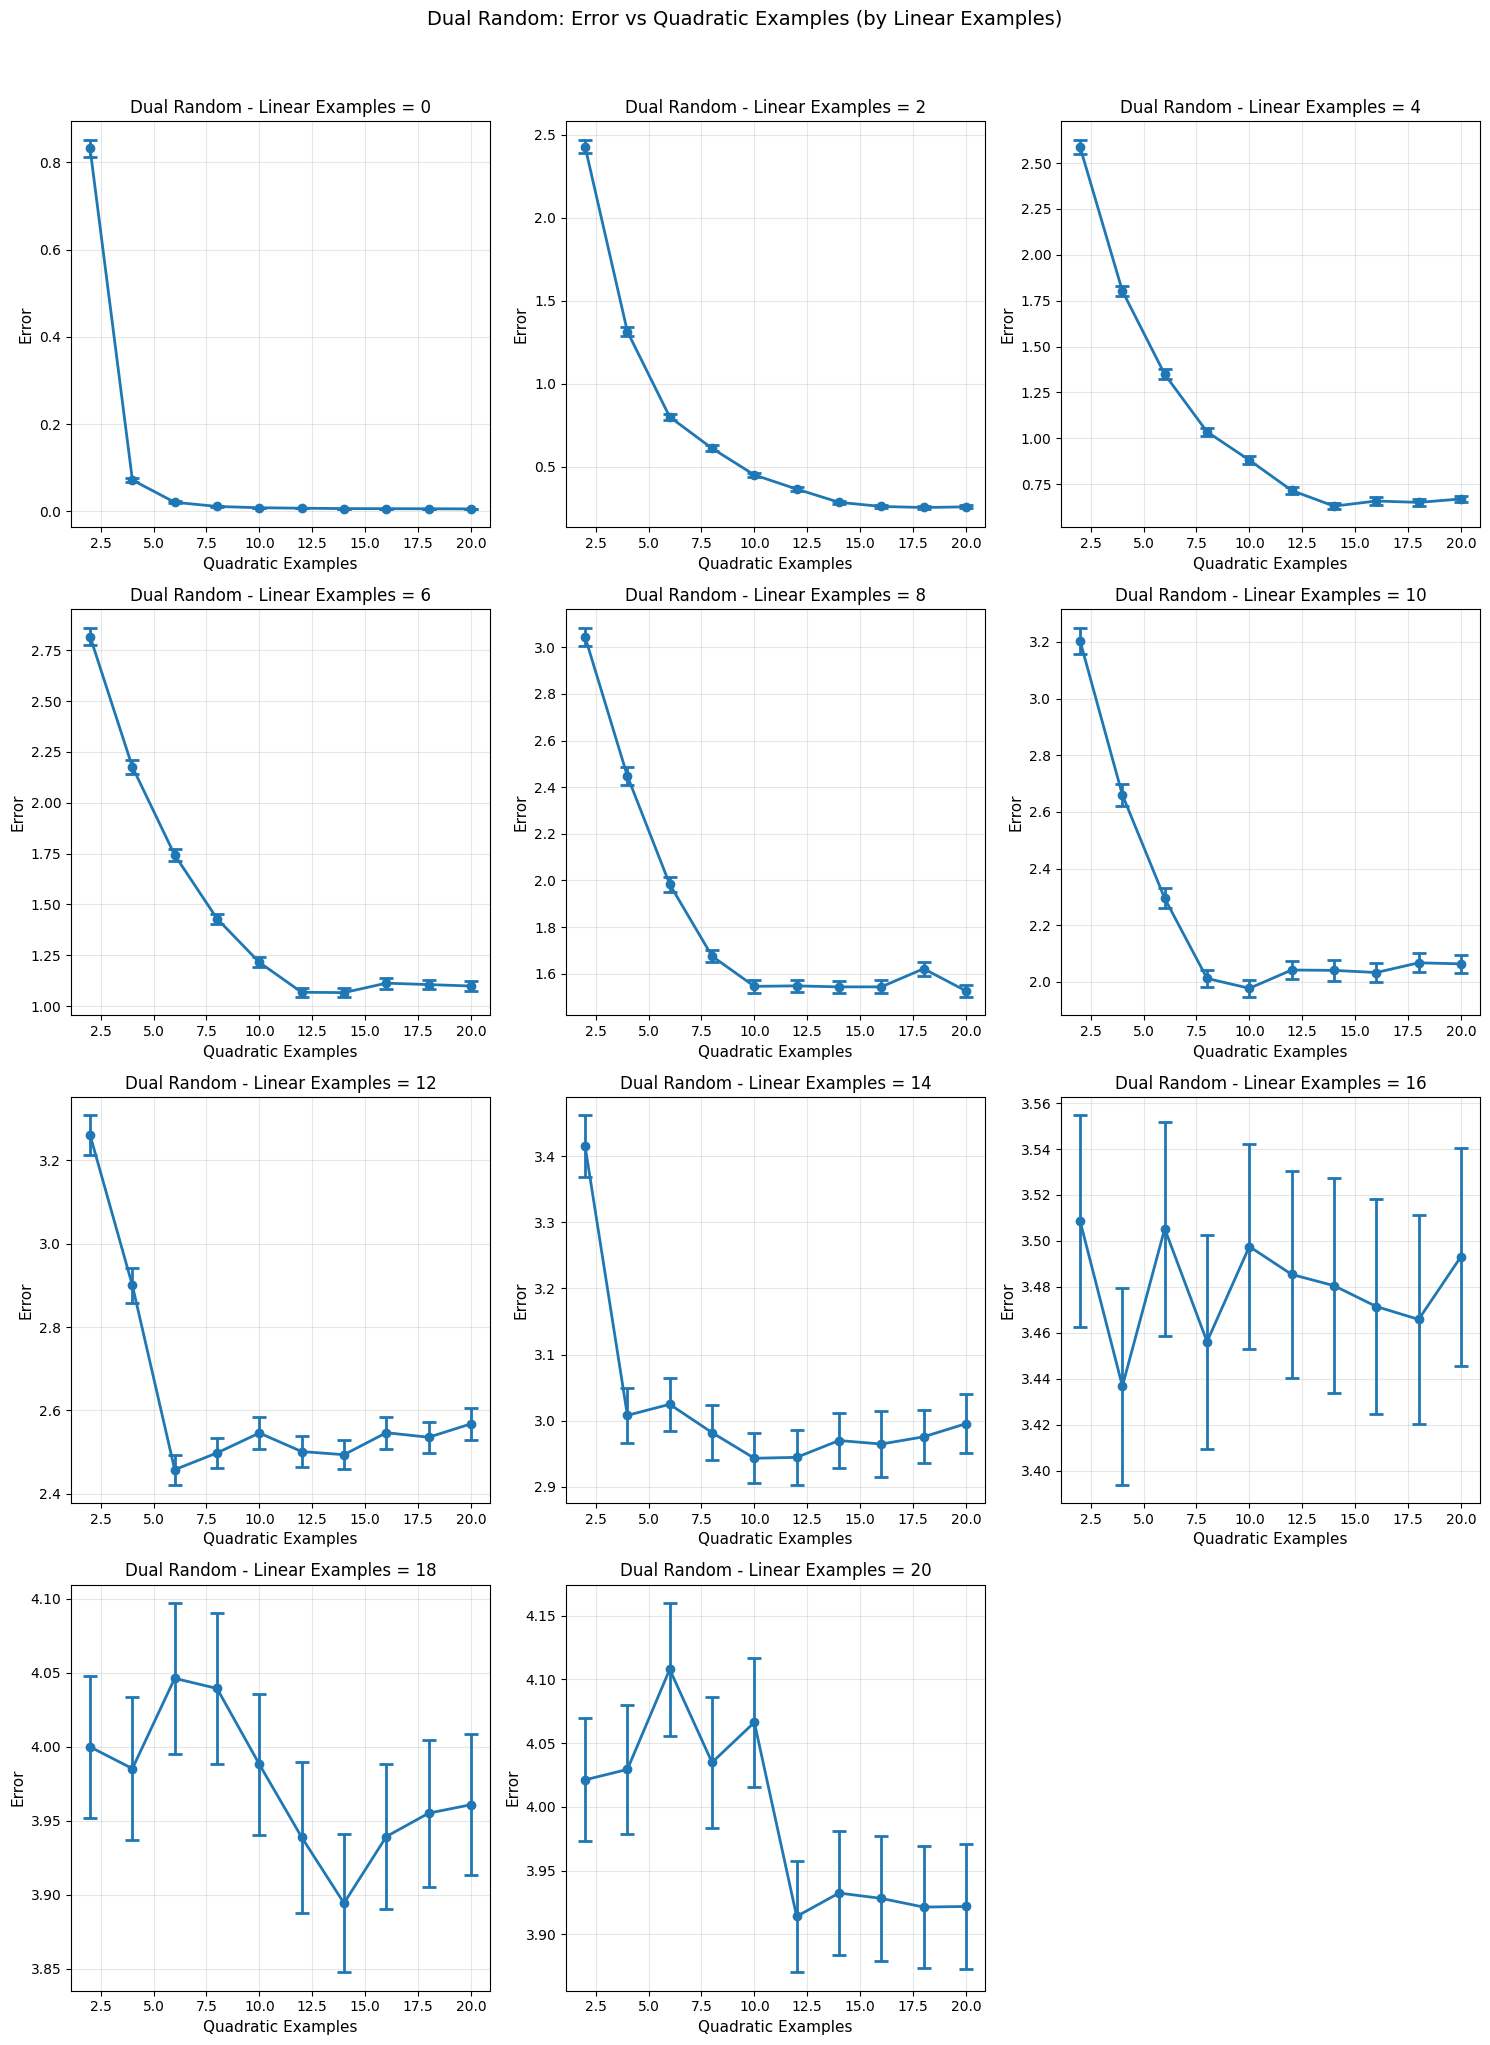

In [ ]:
# Plot all three datasets side by side
datasets = [
    (dual_mixed_mean, dual_mixed_sem, 'Dual Mixed'),
    (dual_sequential_mean, dual_sequential_sem, 'Dual Sequential'),
    (dual_random_mean, dual_random_sem, 'Dual Random')
]

linear_examples = dual_mixed_mean.columns.values  # Columns = Linear Examples
quadratic_examples = dual_mixed_mean.index.values  # Rows (index) = Quadratic Examples
n_plots = len(linear_examples)

for dataset_mean, dataset_sem, dataset_name in datasets:
    n_cols = 3
    n_rows = (n_plots + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    axes = axes.flatten() if n_plots > 1 else [axes]
    
    for idx, n_linear in enumerate(linear_examples):
        ax = axes[idx]
        
        mean_values = dataset_mean.loc[n_linear].values
        sem_values = dataset_sem.loc[n_linear].values
        
        ax.errorbar(quadratic_examples, mean_values, yerr=sem_values, 
                    marker='o', capsize=5, capthick=2, linewidth=2, markersize=6)
        
        ax.set_xlabel('Linear Examples', fontsize=11)
        ax.set_ylabel('Error', fontsize=11)
        ax.set_title(f'{dataset_name} - Linear Examples = {n_linear}', fontsize=12)
        ax.grid(True, alpha=0.3)
    
    for idx in range(n_plots, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle(f'{dataset_name}: Error vs Quadratic Examples (by Linear Examples)', 
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

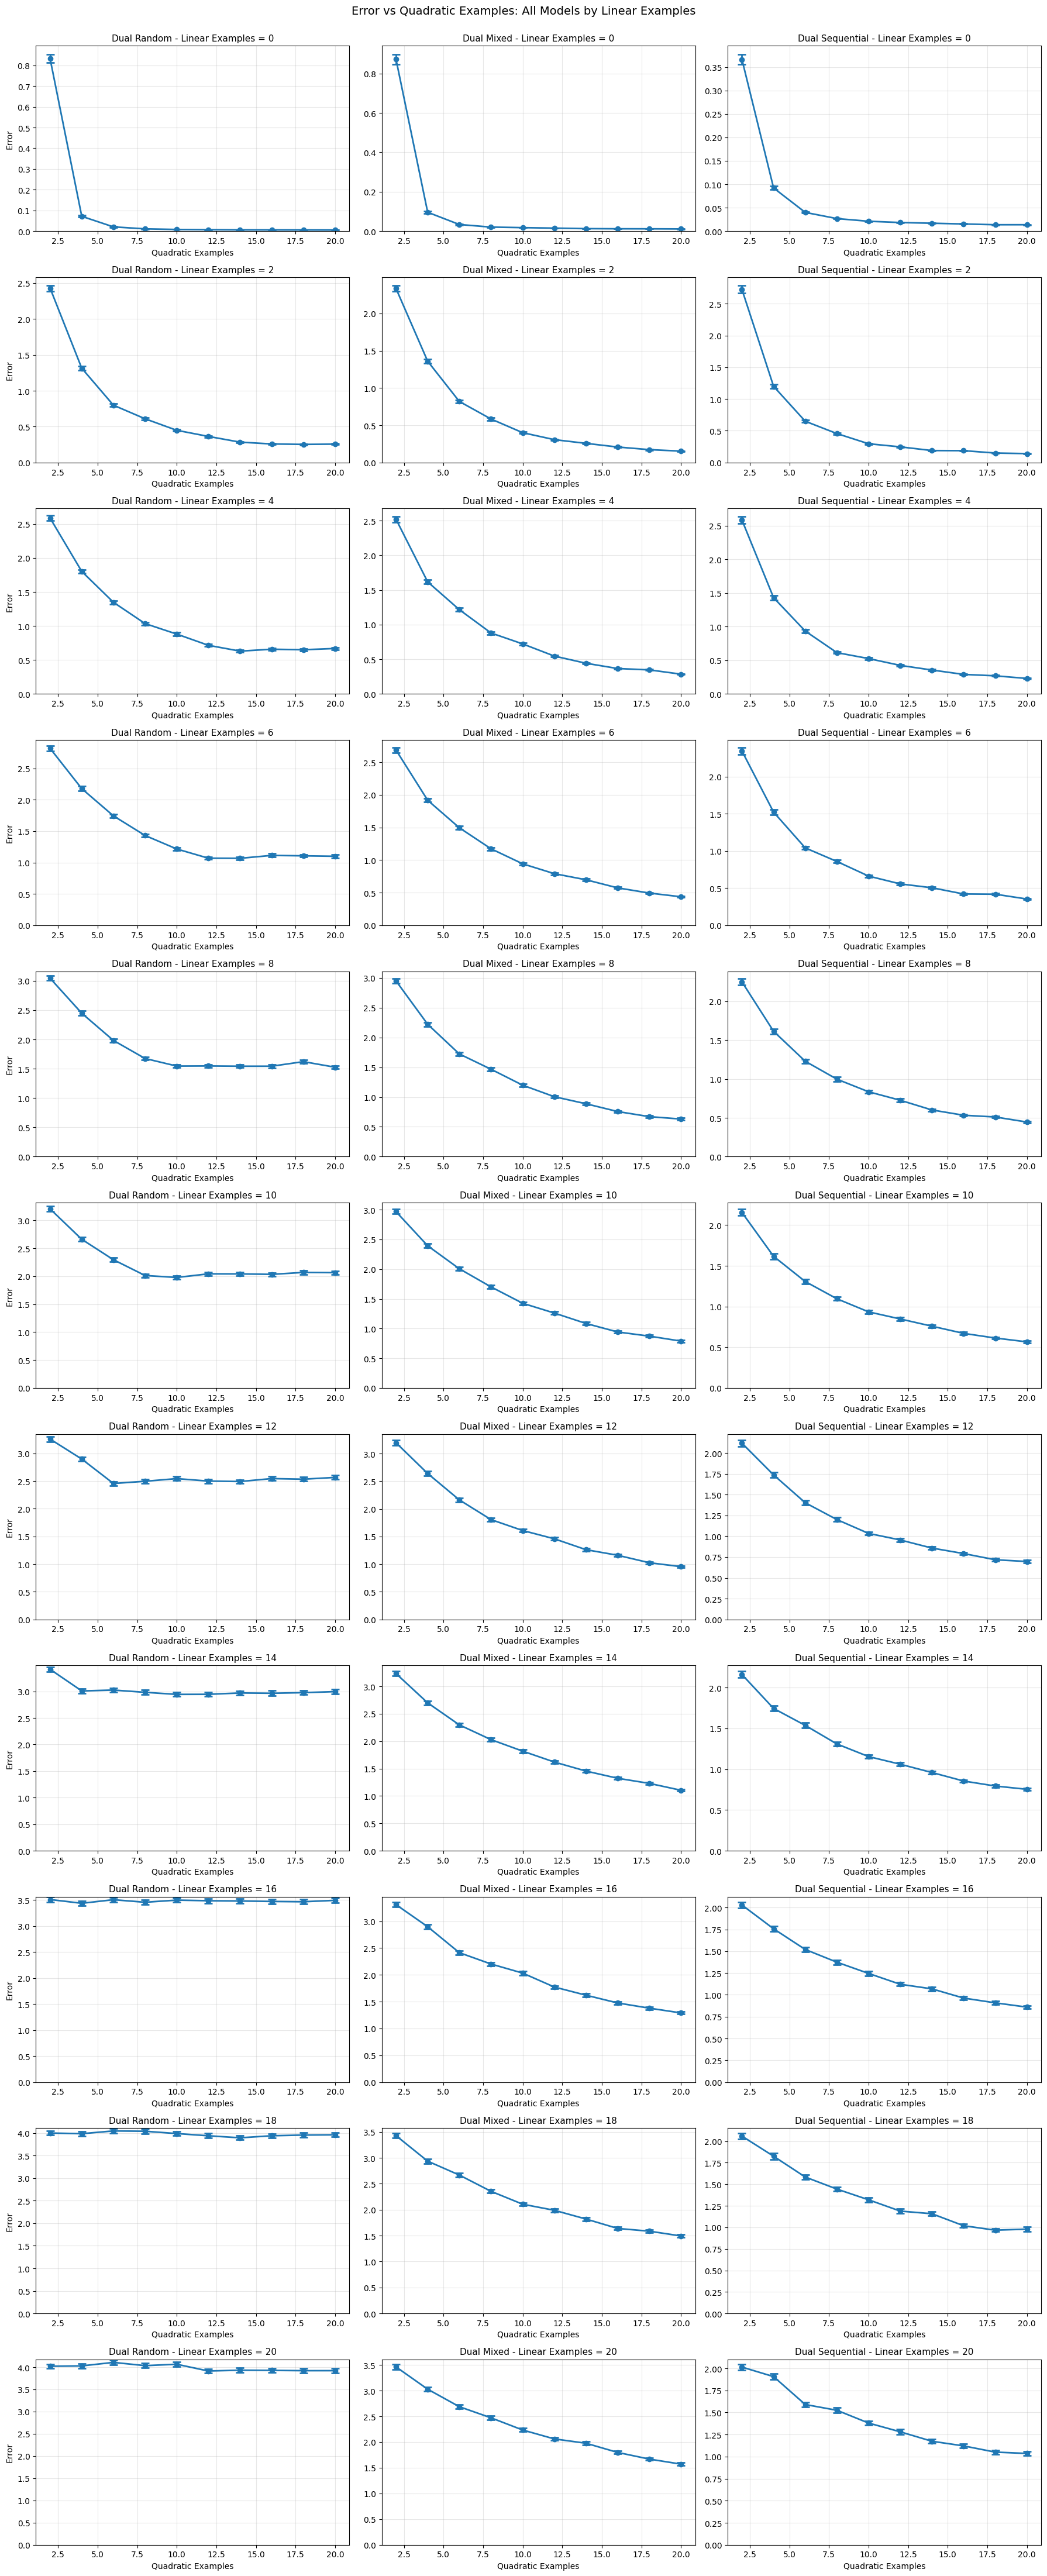

In [63]:
import matplotlib.pyplot as plt
import numpy as np

# Plot layout: each row = one linear example count, 3 columns = 3 models
linear_examples = dual_mixed_mean.columns.values  # Columns = Linear Examples
quadratic_examples = dual_mixed_mean.index.values  # Rows (index) = Quadratic Examples

n_rows = len(linear_examples)
n_cols = 3  # One for each model

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4*n_rows))

# If only one row, make sure axes is 2D
if n_rows == 1:
    axes = axes.reshape(1, -1)

# Order: dual_random, dual_mixed, dual_sequential
datasets = [
    (dual_random_mean, dual_random_sem, 'Dual Random'),
    (dual_mixed_mean, dual_mixed_sem, 'Dual Mixed'),
    (dual_sequential_mean, dual_sequential_sem, 'Dual Sequential')
]

for row_idx, n_linear in enumerate(linear_examples):
    for col_idx, (mean_df, sem_df, name) in enumerate(datasets):
        ax = axes[row_idx, col_idx]
        
        mean_values = mean_df[n_linear].values
        sem_values = sem_df[n_linear].values
        
        ax.errorbar(quadratic_examples, mean_values, yerr=sem_values, 
                    marker='o', capsize=5, capthick=2, linewidth=2, markersize=6)
        
        ax.set_xlabel('Quadratic Examples', fontsize=10)
        if col_idx == 0:  # Only label y-axis on leftmost plots
            ax.set_ylabel('Error', fontsize=10)
        ax.set_title(f'{name} - Linear Examples = {n_linear}', fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(bottom=0)  # Start y-axis at 0

plt.suptitle('Error vs Quadratic Examples: All Models by Linear Examples', 
             fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

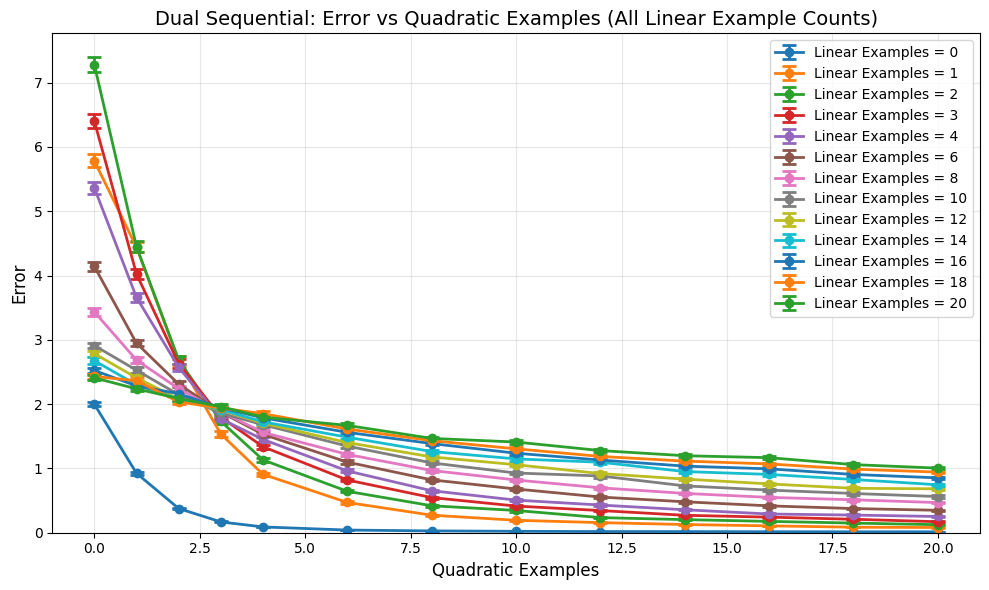

In [73]:
import matplotlib.pyplot as plt
import numpy as np

# Plot all dual sequential lines on one graph
linear_examples = dual_sequential_mean.columns.values  # Columns = Linear Examples
quadratic_examples = dual_sequential_mean.index.values  # Rows (index) = Quadratic Examples

fig, ax = plt.subplots(figsize=(10, 6))

# Plot all lines for dual sequential, one for each linear example count
for n_linear in linear_examples:
    mean_values = dual_sequential_mean.loc[n_linear].values
    sem_values = dual_sequential_sem.loc[n_linear].values
    
    ax.errorbar(quadratic_examples, mean_values, yerr=sem_values, 
                marker='o', capsize=5, capthick=2, linewidth=2, markersize=6,
                label=f'Linear Examples = {n_linear}')

ax.set_xlabel('Linear Examples', fontsize=12)
ax.set_ylabel('Error', fontsize=12)
ax.set_title('Dual Sequential: Error vs Quadratic Examples (All Linear Example Counts)', 
             fontsize=14)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)  # Start y-axis at 0
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


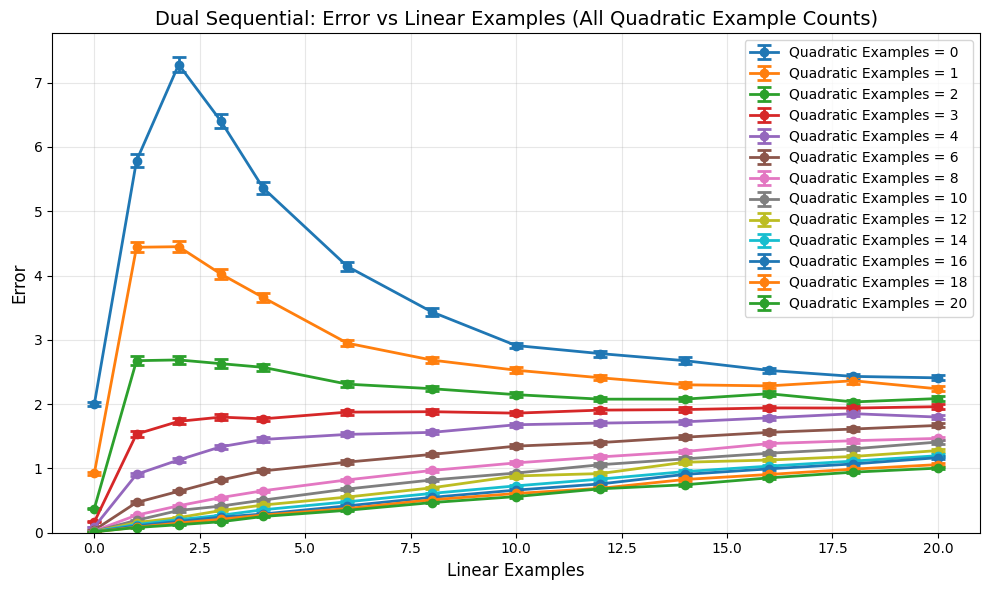

In [74]:
import matplotlib.pyplot as plt
import numpy as np

# Plot all dual sequential lines on one graph (swapped axes)
linear_examples = dual_sequential_mean.columns.values  # Columns = Linear Examples
quadratic_examples = dual_sequential_mean.index.values  # Rows (index) = Quadratic Examples

fig, ax = plt.subplots(figsize=(10, 6))

# Plot all lines for dual sequential, one for each quadratic example count
for n_quadratic in quadratic_examples:
    mean_values = dual_sequential_mean[n_quadratic].values
    sem_values = dual_sequential_sem[n_quadratic].values
    
    ax.errorbar(linear_examples, mean_values, yerr=sem_values, 
                marker='o', capsize=5, capthick=2, linewidth=2, markersize=6,
                label=f'Quadratic Examples = {n_quadratic}')

ax.set_xlabel('Linear Examples', fontsize=12)
ax.set_ylabel('Error', fontsize=12)
ax.set_title('Dual Sequential: Error vs Linear Examples (All Quadratic Example Counts)', 
             fontsize=14)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)  # Start y-axis at 0
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


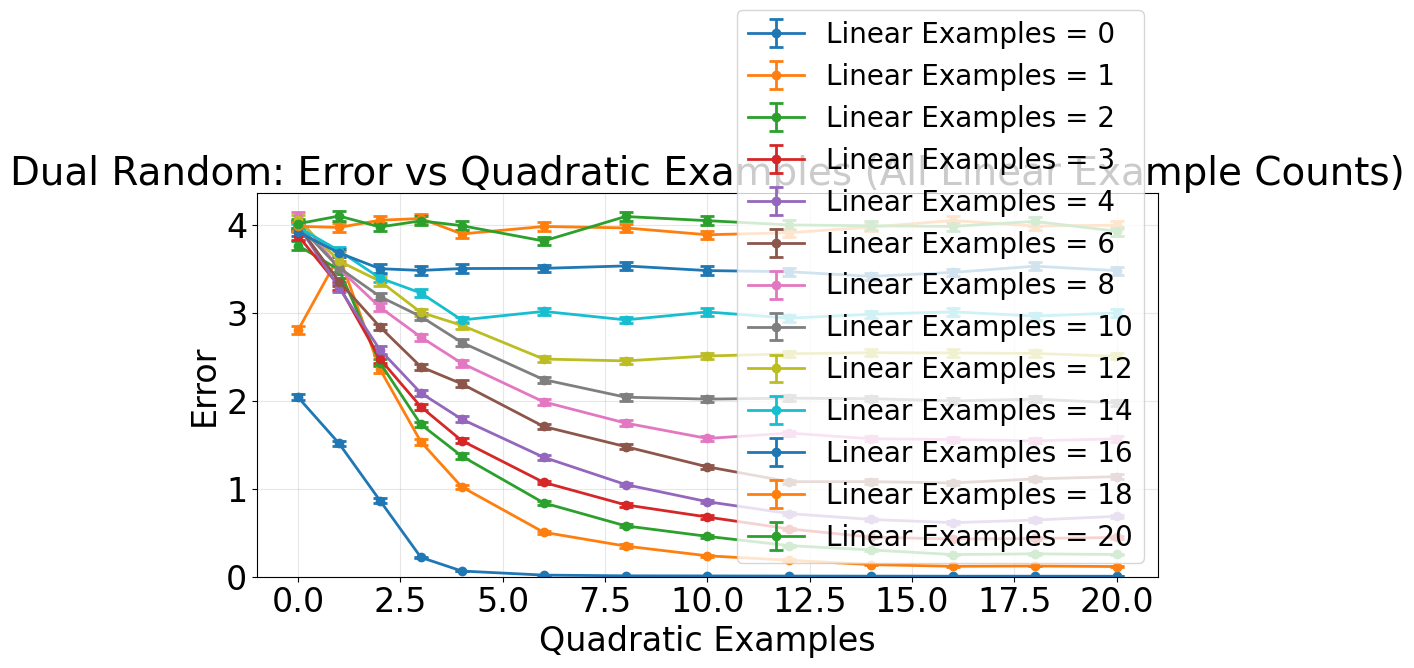

In [75]:
import matplotlib.pyplot as plt
import numpy as np

# Plot all dual random lines on one graph
linear_examples = dual_random_mean.columns.values  # Columns = Linear Examples
quadratic_examples = dual_random_mean.index.values  # Rows (index) = Quadratic Examples

fig, ax = plt.subplots(figsize=(10, 6))

# Plot all lines for dual random, one for each linear example count
for n_linear in linear_examples:
    mean_values = dual_random_mean.loc[n_linear].values
    sem_values = dual_random_sem.loc[n_linear].values
    
    ax.errorbar(quadratic_examples, mean_values, yerr=sem_values, 
                marker='o', capsize=5, capthick=2, linewidth=2, markersize=6,
                label=f'Linear Examples = {n_linear}')

ax.set_xlabel('Linear Examples', fontsize=24)
ax.set_ylabel('Error', fontsize=24)
ax.set_title('Dual Random: Error vs Quadratic Examples (All Linear Example Counts)', 
             fontsize=28)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)  # Start y-axis at 0
ax.legend(fontsize=20)
ax.tick_params(labelsize=24)

plt.tight_layout()
plt.show()


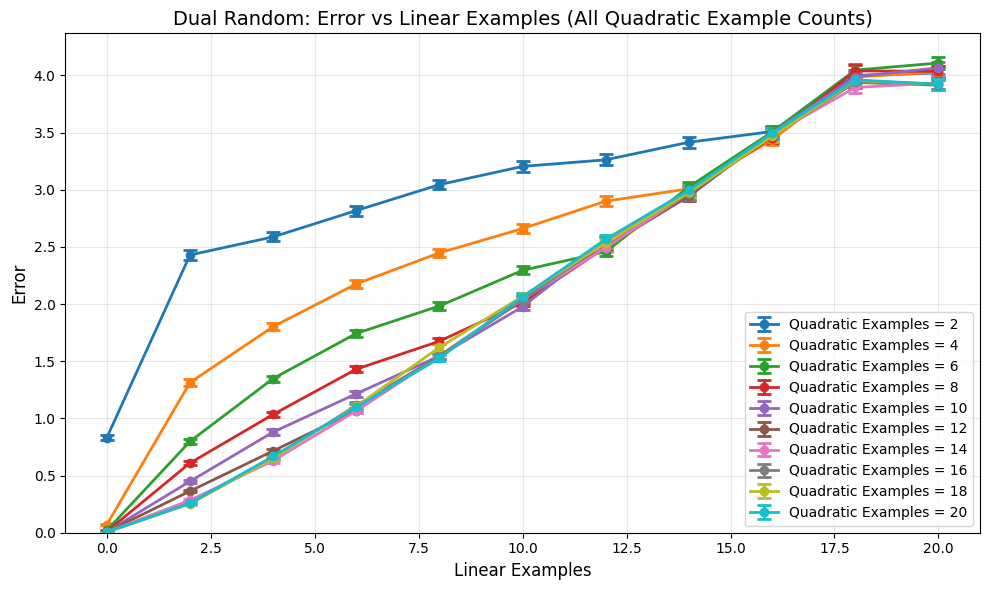

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plot all dual random lines on one graph (swapped axes)
linear_examples = dual_random_mean.columns.values  # Columns = Linear Examples
quadratic_examples = dual_random_mean.index.values  # Rows (index) = Quadratic Examples

fig, ax = plt.subplots(figsize=(10, 6))

# Plot all lines for dual random, one for each quadratic example count
for n_quadratic in quadratic_examples:
    mean_values = dual_random_mean[n_quadratic].values
    sem_values = dual_random_sem[n_quadratic].values
    
    ax.errorbar(linear_examples, mean_values, yerr=sem_values, 
                marker='o', capsize=5, capthick=2, linewidth=2, markersize=6,
                label=f'Quadratic Examples = {n_quadratic}')

ax.set_xlabel('Linear Examples', fontsize=24)
ax.set_ylabel('Error', fontsize=24)
ax.set_title('Dual Random: Error vs Linear Examples (All Quadratic Example Counts)', 
             fontsize=28)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)  # Start y-axis at 0
ax.legend(fontsize=20)
ax.tick_params(labelsize=24)

plt.tight_layout()
plt.show()


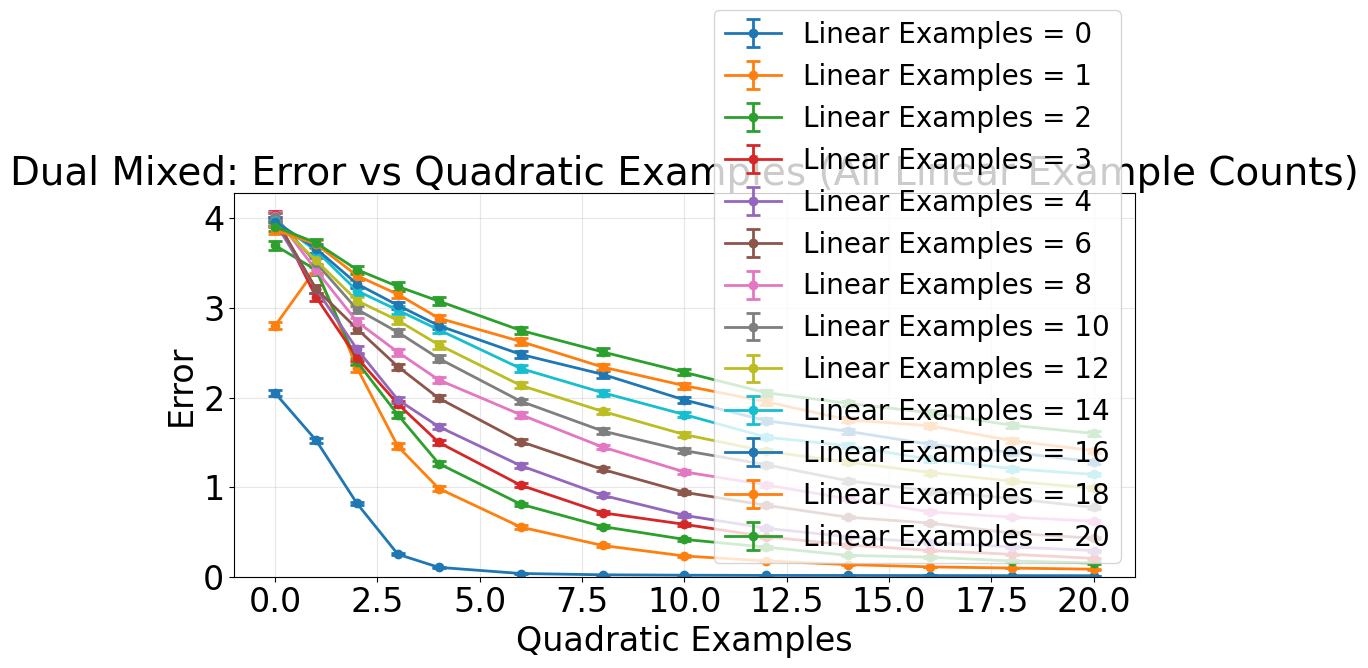

In [76]:
import matplotlib.pyplot as plt
import numpy as np

# Plot all dual mixed lines on one graph
linear_examples = dual_mixed_mean.columns.values  # Columns = Linear Examples
quadratic_examples = dual_mixed_mean.index.values  # Rows (index) = Quadratic Examples

fig, ax = plt.subplots(figsize=(10, 6))

# Plot all lines for dual mixed, one for each linear example count
for n_linear in linear_examples:
    mean_values = dual_mixed_mean.loc[n_linear].values
    sem_values = dual_mixed_sem.loc[n_linear].values
    
    ax.errorbar(quadratic_examples, mean_values, yerr=sem_values, 
                marker='o', capsize=5, capthick=2, linewidth=2, markersize=6,
                label=f'Linear Examples = {n_linear}')

ax.set_xlabel('Linear Examples', fontsize=24)
ax.set_ylabel('Error', fontsize=24)
ax.set_title('Dual Mixed: Error vs Quadratic Examples (All Linear Example Counts)', 
             fontsize=28)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)  # Start y-axis at 0
ax.legend(fontsize=20)
ax.tick_params(labelsize=24)

plt.tight_layout()
plt.show()


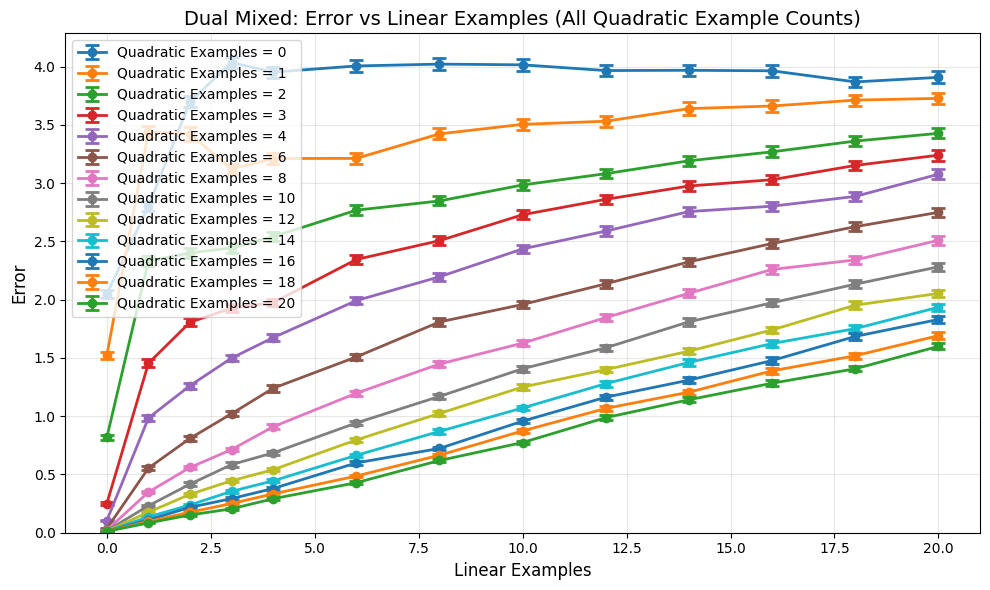

In [77]:
import matplotlib.pyplot as plt
import numpy as np

# Plot all dual mixed lines on one graph (swapped axes)
linear_examples = dual_mixed_mean.columns.values  # Columns = Linear Examples
quadratic_examples = dual_mixed_mean.index.values  # Rows (index) = Quadratic Examples

fig, ax = plt.subplots(figsize=(10, 6))

# Plot all lines for dual mixed, one for each quadratic example count
for n_quadratic in quadratic_examples:
    mean_values = dual_mixed_mean[n_quadratic].values
    sem_values = dual_mixed_sem[n_quadratic].values
    
    ax.errorbar(linear_examples, mean_values, yerr=sem_values, 
                marker='o', capsize=5, capthick=2, linewidth=2, markersize=6,
                label=f'Quadratic Examples = {n_quadratic}')

ax.set_xlabel('Linear Examples', fontsize=12)
ax.set_ylabel('Error', fontsize=12)
ax.set_title('Dual Mixed: Error vs Linear Examples (All Quadratic Example Counts)', 
             fontsize=14)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)  # Start y-axis at 0
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


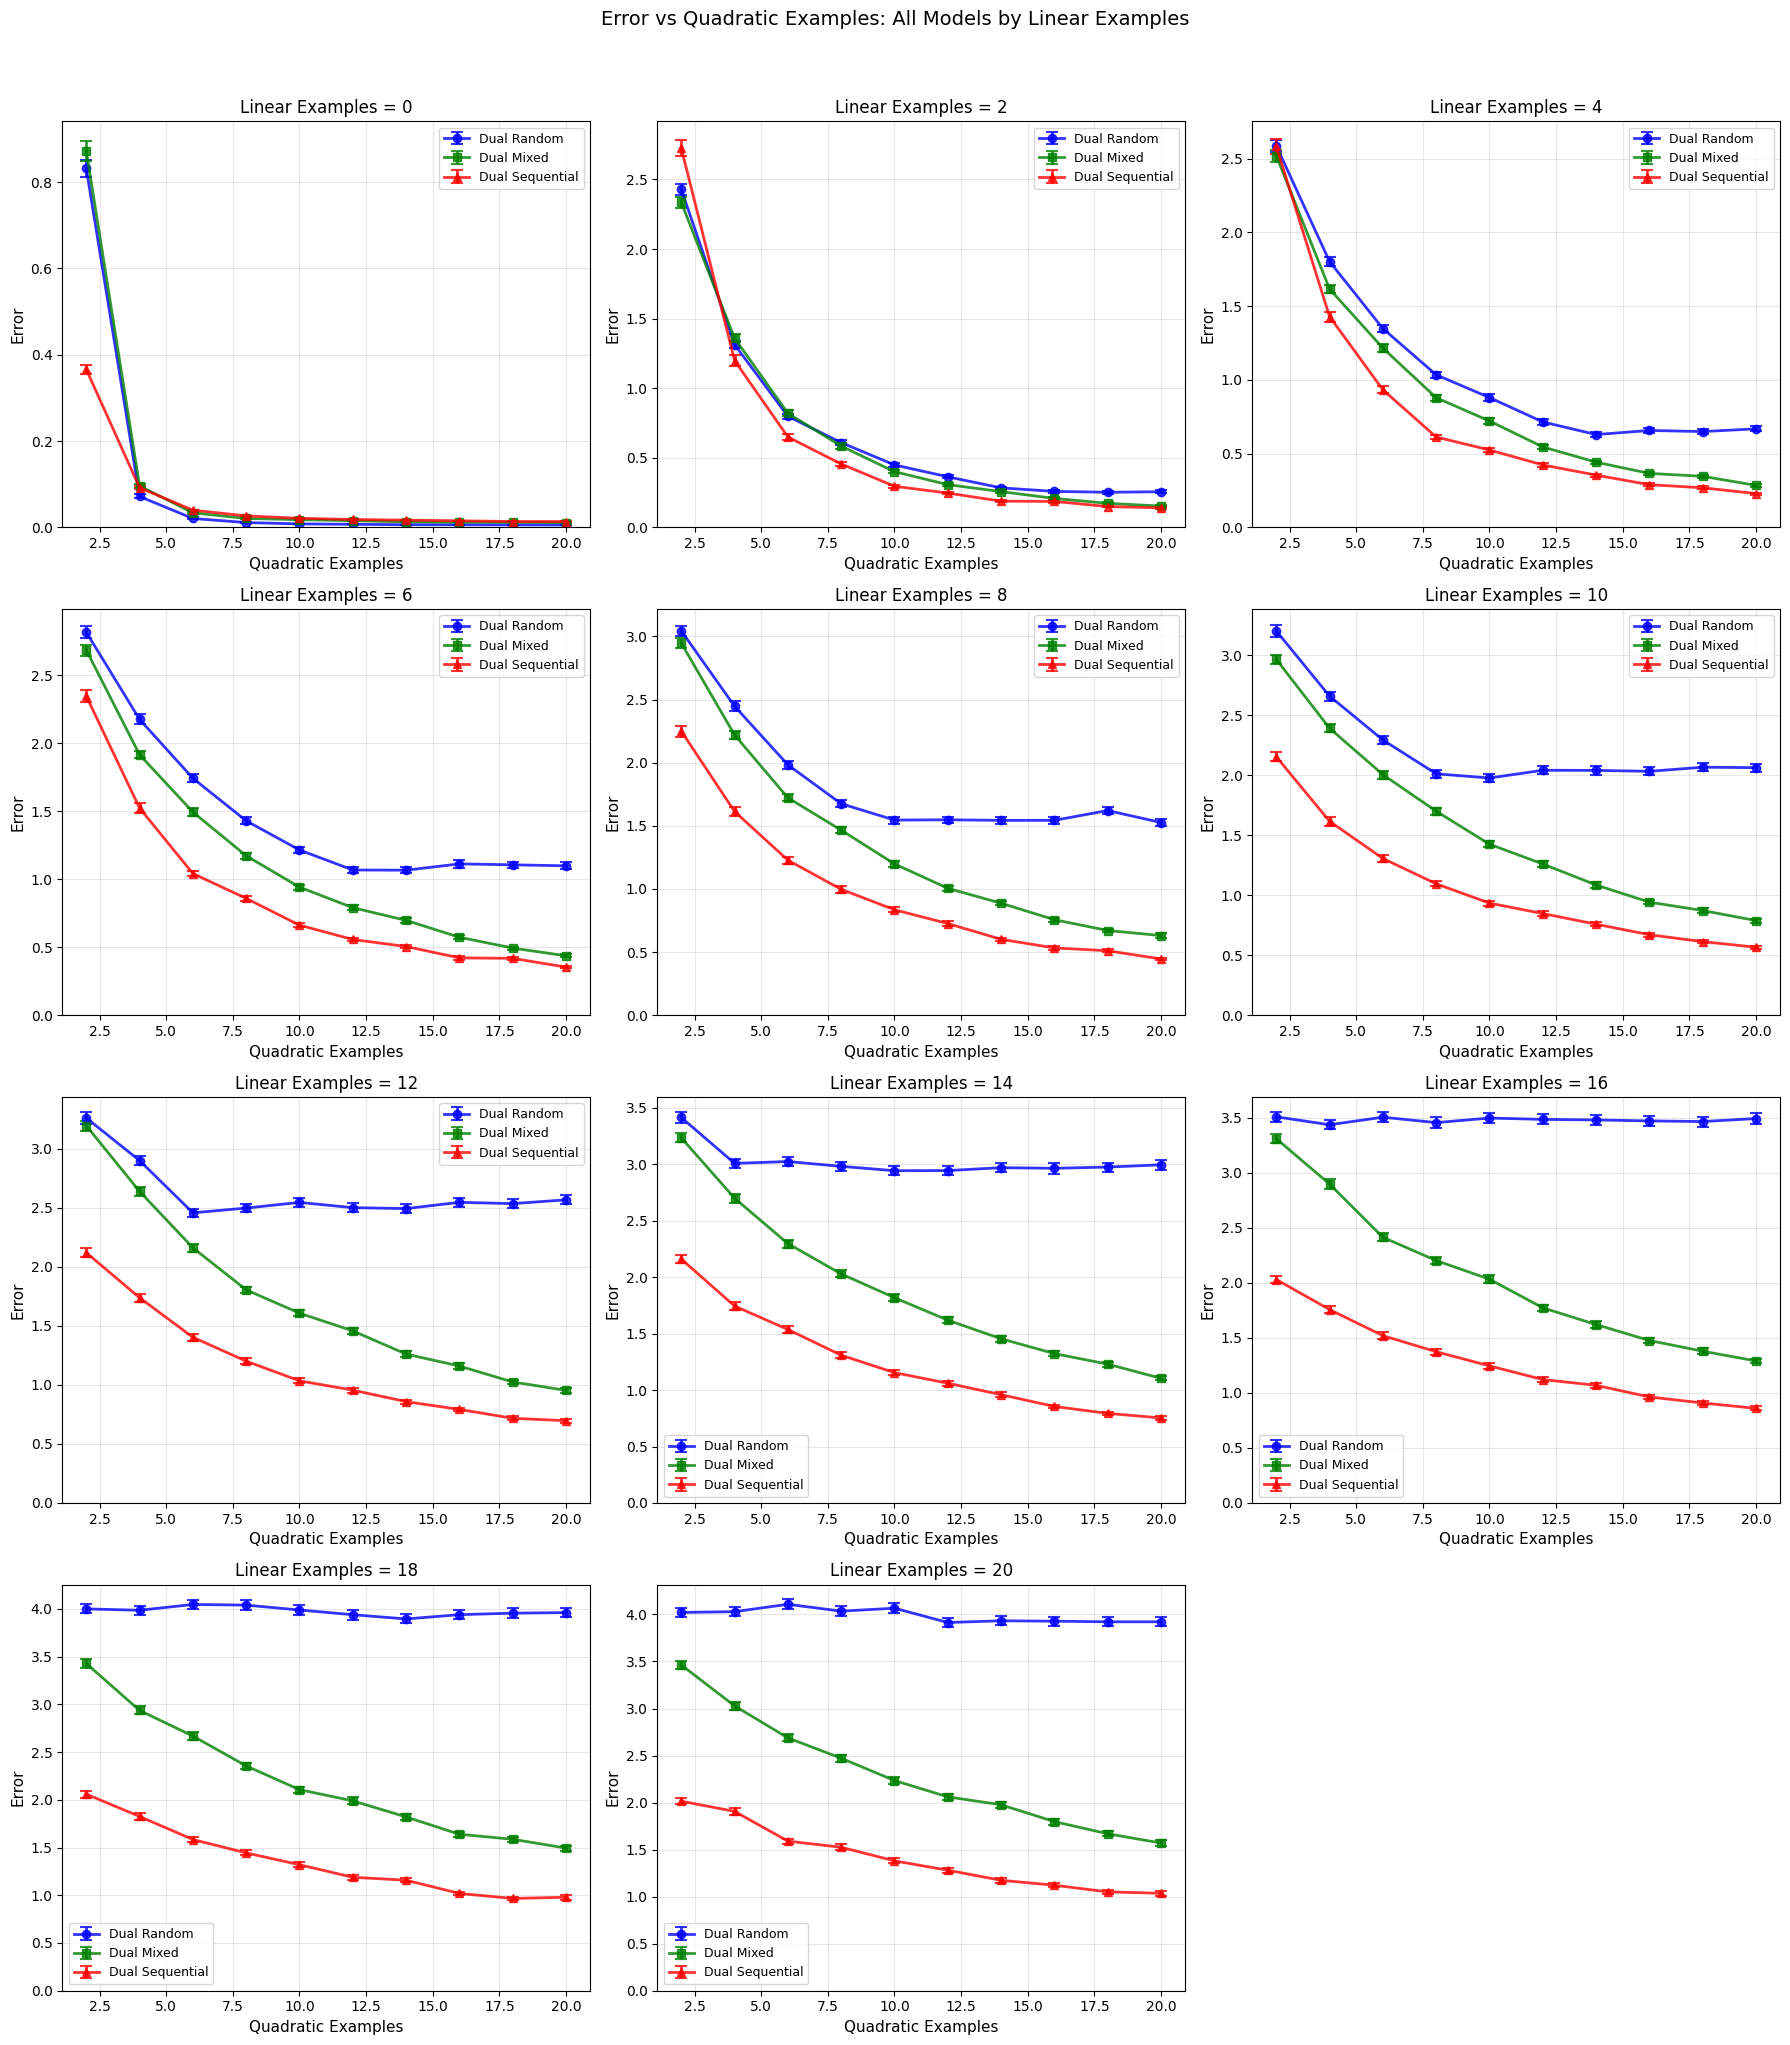

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plot one graph per linear example count, all three models on each
linear_examples = dual_mixed_mean.columns.values  # Columns = Linear Examples
quadratic_examples = dual_mixed_mean.index.values  # Rows (index) = Quadratic Examples

n_plots = len(linear_examples)
n_cols = 3  # Number of columns in subplot grid
n_rows = (n_plots + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten() if n_plots > 1 else [axes]

# Colors and markers for each model
model_styles = {
    'Dual Random': {'color': 'blue', 'marker': 'o'},
    'Dual Mixed': {'color': 'green', 'marker': 's'},
    'Dual Sequential': {'color': 'red', 'marker': '^'}
}

datasets = [
    (dual_random_mean, dual_random_sem, 'Dual Random'),
    (dual_mixed_mean, dual_mixed_sem, 'Dual Mixed'),
    (dual_sequential_mean, dual_sequential_sem, 'Dual Sequential')
]

for idx, n_linear in enumerate(linear_examples):
    ax = axes[idx]
    
    # Plot all three models on this subplot
    for mean_df, sem_df, model_name in datasets:
        mean_values = mean_df[n_linear].values
        sem_values = sem_df[n_linear].values
        style = model_styles[model_name]
        
        ax.errorbar(quadratic_examples, mean_values, yerr=sem_values, 
                    marker=style['marker'], capsize=4, capthick=1.5, 
                    linewidth=2, markersize=6, label=model_name, 
                    color=style['color'], alpha=0.8)
    
    ax.set_xlabel('Quadratic Examples', fontsize=11)
    ax.set_ylabel('Error', fontsize=11)
    ax.set_title(f'Linear Examples = {n_linear}', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=9)
    
# Hide unused subplots
for idx in range(n_plots, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Error vs Quadratic Examples: All Models by Linear Examples', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

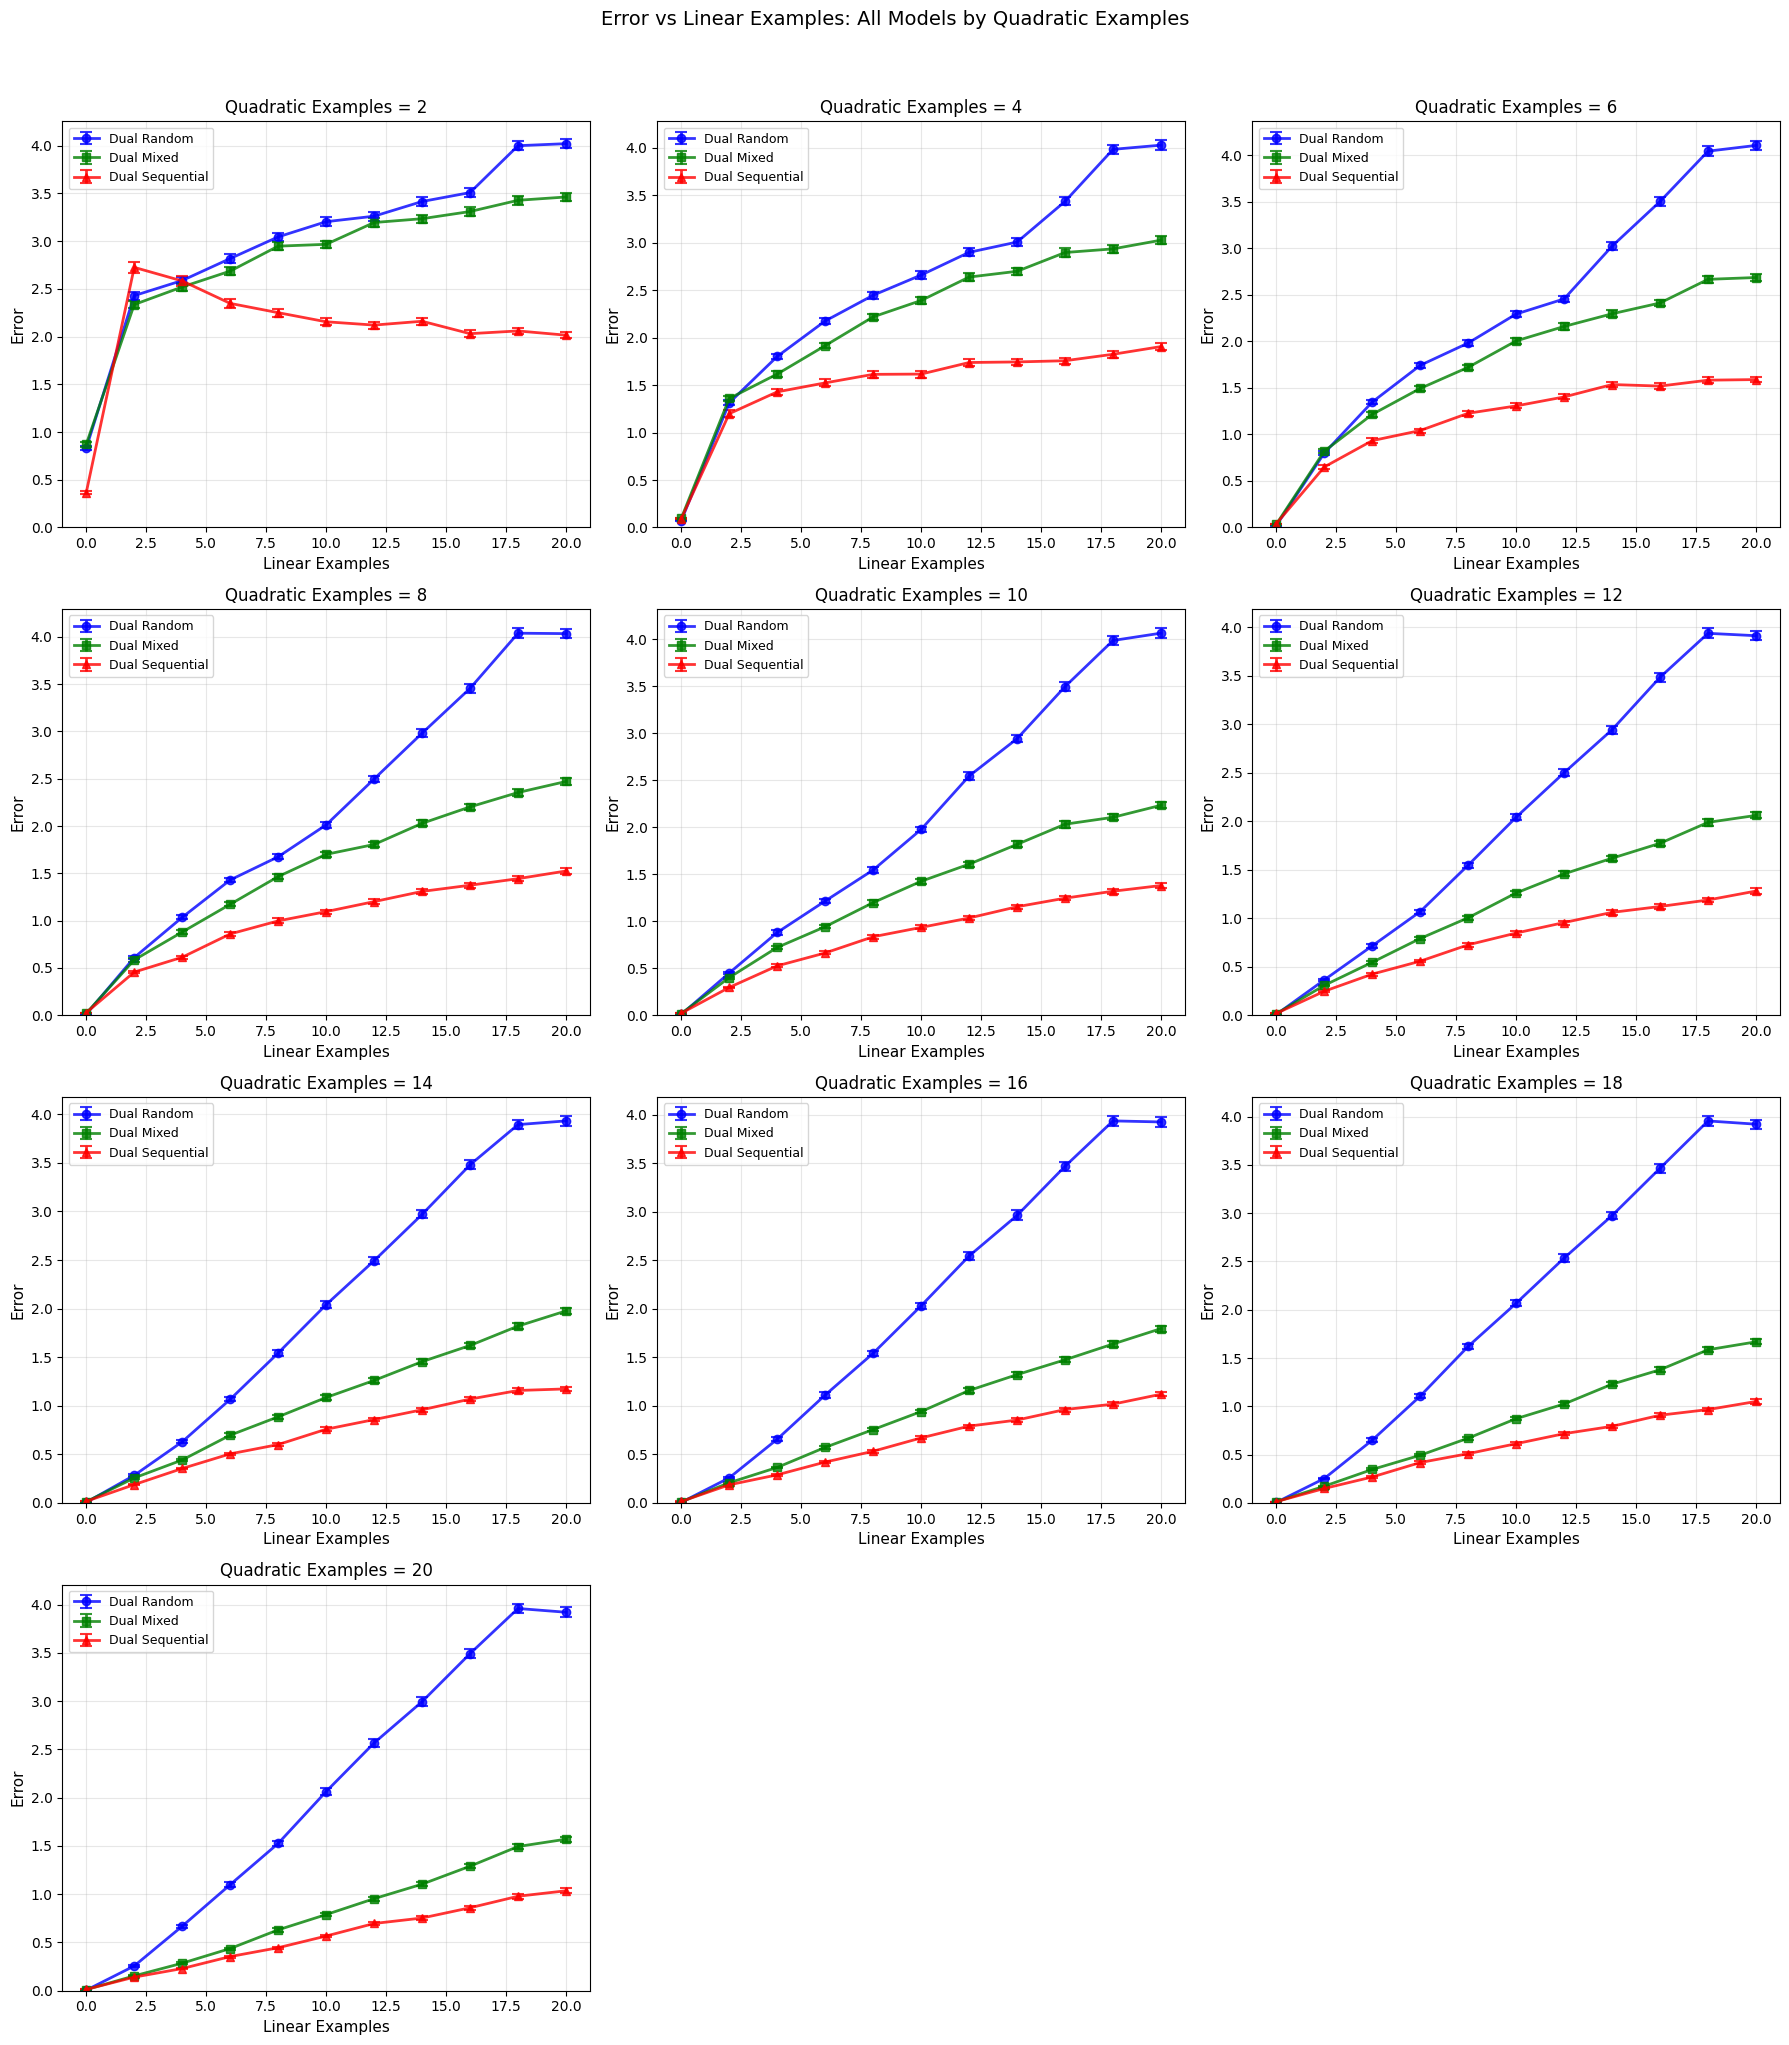

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plot one graph per quadratic example count, all three models on each
linear_examples = dual_mixed_mean.columns.values  # Columns = Linear Examples
quadratic_examples = dual_mixed_mean.index.values  # Rows (index) = Quadratic Examples

n_plots = len(quadratic_examples)
n_cols = 3  # Number of columns in subplot grid
n_rows = (n_plots + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten() if n_plots > 1 else [axes]

# Colors and markers for each model
model_styles = {
    'Dual Random': {'color': 'blue', 'marker': 'o'},
    'Dual Mixed': {'color': 'green', 'marker': 's'},
    'Dual Sequential': {'color': 'red', 'marker': '^'}
}

datasets = [
    (dual_random_mean, dual_random_sem, 'Dual Random'),
    (dual_mixed_mean, dual_mixed_sem, 'Dual Mixed'),
    (dual_sequential_mean, dual_sequential_sem, 'Dual Sequential')
]

for idx, n_quadratic in enumerate(quadratic_examples):
    ax = axes[idx]
    
    # Plot all three models on this subplot
    for mean_df, sem_df, model_name in datasets:
        mean_values = mean_df[n_quadratic].values
        sem_values = sem_df[n_quadratic].values
        style = model_styles[model_name]
        
        ax.errorbar(linear_examples, mean_values, yerr=sem_values, 
                    marker=style['marker'], capsize=4, capthick=1.5, 
                    linewidth=2, markersize=6, label=model_name, 
                    color=style['color'], alpha=0.8)
    
    ax.set_xlabel('Linear Examples', fontsize=11)
    ax.set_ylabel('Error', fontsize=11)
    ax.set_title(f'Quadratic Examples = {n_quadratic}', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=9)
    
# Hide unused subplots
for idx in range(n_plots, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Error vs Linear Examples: All Models by Quadratic Examples', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
